In [113]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn import preprocessing

# TRAIN

In [114]:
train = pd.read_pickle('output/relationships/CURING_SICK/SICK_TRAIN_1.csv.pickle')
train 

,Texto,Hipotesis,TextoL,HipotesisL,dicEntT,dicEntH,ConteosR,ConteosG1,ConteosG2,ConteosG3,...,s2,sinT,sinH,antT,antH,HipT,HipH,hipT,hipH,clases
0,a group of kids is playing in a yard and an ol...,a group of boys in a yard is playing and a man...,"[a, group, of, kid, be, play, in, a, yard, and...","[a, group, of, boy, in, a, yard, be, play, and...","{'group': {'of'}, 'kid': {}, 'play': {'in', 'b...","{'group': {'of', 'in'}, 'boy': {}, 'yard': {},...","[( group, same, group), ( kid, synonym, boy)...","[( group, same, group), ( kid, synonym, boy)...",[],[],...,"[an, an, of, boy, in, an, yard, stand, play, a...","[{an, o, au, type, aud, group, adenine, deoxya...","[{an, o, au, type, aud, group, adenine, deoxya...","[{}, {separate, individuals, solo, individual}...","[{}, {separate, individuals, solo, individual}...","[{on, an, o, au, basketball_league, blood_grou...","[{on, an, o, au, basketball_league, blood_grou...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...",NEUTRAL
1,a group of children is playing in the house an...,a group of kids is playing in a yard and an ol...,"[a, group, of, child, be, play, in, the, house...","[a, group, of, kid, be, play, in, a, yard, and...","{'group': {'of'}, 'child': {}, 'play': {'in', ...","{'group': {'of'}, 'kid': {}, 'play': {'in', 'b...","[( group, same, group), ( child, synonym, ki...","[( group, same, group), ( child, synonym, ki...","[( house, antonym, yard), ( child, antonym, ...",[],...,"[group, group, of, house, stand, house, in, gr...","[{an, o, au, type, aud, group, adenine, deoxya...","[{an, o, au, type, aud, group, adenine, deoxya...","[{}, {separate, individuals, solo, individual}...","[{}, {separate, individuals, solo, individual}...","[{on, an, o, au, basketball_league, blood_grou...","[{on, an, o, au, basketball_league, blood_grou...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...",NEUTRAL
2,the young boys are playing outdoors and the ma...,the kids are playing outdoors near a man with ...,"[the, young, boy, be, play, outdoors, and, the...","[the, kid, be, play, outdoors, near, a, man, w...","{'young': {}, 'boy': {'young'}, 'play': {'outd...","{'kid': {}, 'play': {'near', 'outdoors', 'be'}...","[(young boy, synonym, kid), ( outdoors, same,...","[(young boy, synonym, kid), ( outdoors, same,...",[],"[(near outdoors play, is_a, outdoors play), (w...",...,"[man, kid, be, play, outdoors, near, a, boy, w...","[{ye, the}, {youth, youthful, juvenile, thomas...","[{ye, the}, {child, bairn, kid, tease, thomas_...","[{}, {senior, old, aged, mature}, {female, sis...","[{}, {adult}, {or_not, existing, exist, not, t...","[{always_higher_than, 640_acres_in_square_mile...","[{always_higher_than, 640_acres_in_square_mile...","[{natheless, ye, nevertheless, act_maggot, nev...","[{natheless, ye, nevertheless, act_maggot, nev...",ENTAILMENT
3,the kids are playing outdoors near a man with ...,a group of kids is playing in a yard and an ol...,"[the, kid, be, play, outdoors, near, a, man, w...","[a, group, of, kid, be, play, in, a, yard, and...","{'kid': {}, 'play': {'near', 'outdoors', 'be'}...","{'group': {'of'}, 'kid': {}, 'play': {'in', 'b...","[(with man, synonym, group), ( kid, same, ki...","[(with man, synonym, group), ( kid, same, ki...","[(near outdoors play, antonym, stand)]","[(yard, synonym, outdoors), (old man, is_a, wi...",...,"[a, a, of, kid, be, play, in, a, yard, and, a,...","[{ye, the}, {child, bairn, kid, tease, thomas_...","[{an, o, au, type, aud, group, adenine, deoxya...","[{}, {adult}, {or_not, existing, exist, not, t...","[{}, {separate, individuals, solo, individual}...","[{always_higher_than, 640_acres_in_square_mile...","[{on, an, o, au, basketball_league, blood_grou...","[{natheless, ye, nevertheless, act_maggot, nev...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...",NEUTRAL
4,the young boys are playing outdoors and the ma...,a group of kids is playing in a 

In [115]:
train=train.drop(['Texto', 'Hipotesis', 'TextoL', 'HipotesisL', 'dicEntT', 'dicEntH',
       'ConteosR', 'ConteosG1', 'ConteosG2', 'ConteosG3', 'ConteosG4','ranking',
       's1','s2', 'sinT', 'sinH', 'antT', 'antH', 'HipT', 'HipH', 'hipT', 'hipH',
       'veredict','veredict_l','veredict_g1','veredict_g2','veredict_g3','veredict_g4',
       'veredict_g1S','veredict_g2S','veredict_g3S','veredict_g4S',],axis=1)


In [116]:
base_evidencia = (train['C_G1'] +  train['C_G3']*0.1) / ( 1 + (train['C_G4']*train['H_G4'] ) )
train['rte'] = base_evidencia.where(train['C_G2'] == 0, 0.0)

<Axes: title={'center': 'rte'}, xlabel='clases'>

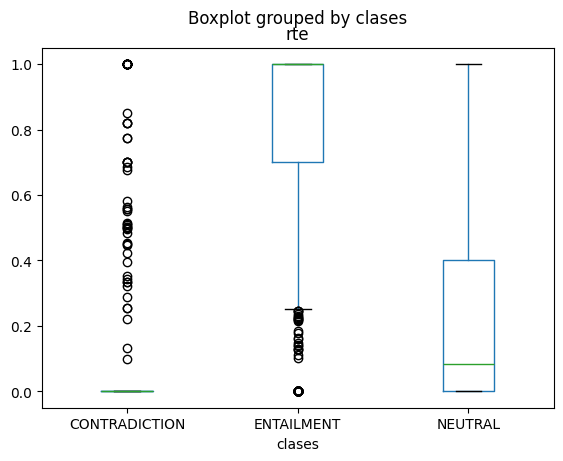

In [117]:
train.boxplot(by="clases",column=['rte'],grid=False)

<Axes: title={'center': 'xIMF_G2_G4'}, xlabel='clases'>

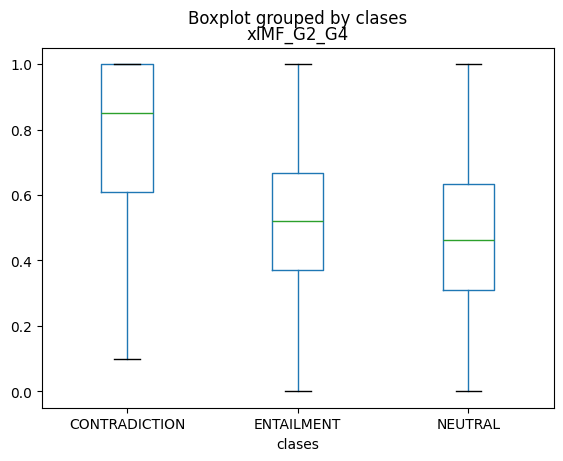

In [118]:
train.boxplot(by="clases",column=["xIMF_G2_G4"],grid=False)

<Axes: title={'center': 'h_h_g1'}, xlabel='clases'>

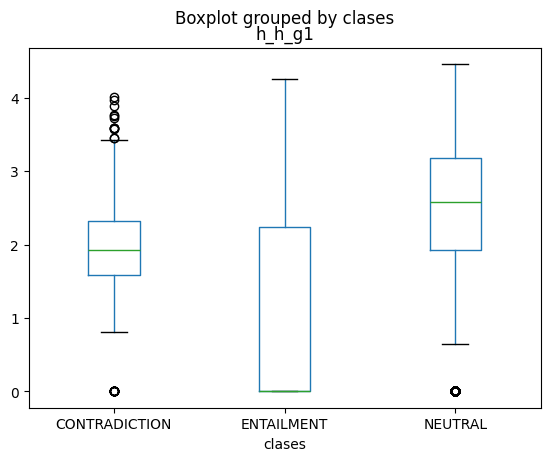

In [119]:
train.boxplot(by="clases",column=["h_h_g1"],grid=False)

In [120]:
train["H-H_G1"]=train["H"]-train["H_G1"]
train["H-H_G2"]=train["H"]-train["H_G2"]
train["H-H_G3"]=train["H"]-train["H_G3"]
train["H-H_G4"]=train["H"]-train["H_G4"]
train["H-H_G1_G2"]=train["H"]-train["H_G1_G2"]
train["H-H_G1_G3"]=train["H"]-train["H_G1_G3"]
train["H-H_G1_G4"]=train["H"]-train["H_G1_G4"]

In [121]:
train.columns.to_list()

['Jaro-Winkler_rit',
 'Jaro-Winkler_rit1',
 'Jaro-Winkler_dsf',
 'Jaro-Winkler_dsf1',
 'Jaro-Winkler_rit2',
 'Jaro-Winkler_rit21',
 'Jaro-Winkler_rte_expert',
 'Jaro-Winkler_rte_expert1',
 'simBoWrel',
 'Jaro-Winkler_ritR',
 'Jaro-Winkler_ritR1',
 'h_p',
 'h_h',
 'h_joint',
 'te',
 'mi',
 'h_p_l',
 'h_h_l',
 'h_joint_l',
 'te_l',
 'mi_l',
 'h_h_g1',
 'h_joint_g1',
 'te_g1',
 'mi_g1',
 'h_h_g2',
 'h_joint_g2',
 'te_g2',
 'mi_g2',
 'h_h_g3',
 'h_joint_g3',
 'te_g3',
 'mi_g3',
 'h_h_g4',
 'h_joint_g4',
 'te_g4',
 'mi_g4',
 'h_h_g1S',
 'h_joint_g1S',
 'te_g1S',
 'mi_g1S',
 'h_h_g2S',
 'h_joint_g2S',
 'te_g2S',
 'mi_g2S',
 'h_h_g3S',
 'h_joint_g3S',
 'te_g3S',
 'mi_g3S',
 'h_h_g4S',
 'h_joint_g4S',
 'te_g4S',
 'mi_g4S',
 'TH',
 'TH_G1',
 'TH_G2',
 'TH_G3',
 'TH_G4',
 'TH_G1_G2',
 'TH_G1_G3',
 'TH_G1_G4',
 'TH_G2_G4',
 'TH_G3_G4',
 'TH_l',
 'H_l',
 'I_l',
 'IF_l',
 'IM_l',
 'THS',
 'THS_G1',
 'THS_G2',
 'THS_G3',
 'THS_G4',
 'THS_G1_G2',
 'THS_G1_G3',
 'THS_G1_G4',
 'THS_G2_G4',
 'THS_G3_G4'

<Axes: title={'center': 'Jaro-Winkler_rte_expert1'}, xlabel='clases'>

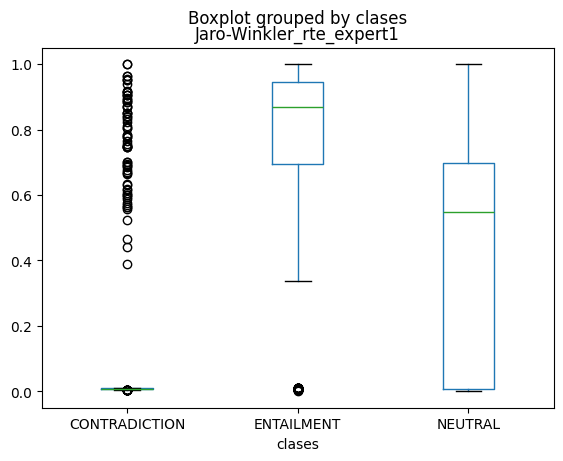

In [122]:
train.boxplot(by="clases",column=["Jaro-Winkler_rte_expert1"],grid=False)

In [123]:
train.columns

Index(['Jaro-Winkler_rit', 'Jaro-Winkler_rit1', 'Jaro-Winkler_dsf',
       'Jaro-Winkler_dsf1', 'Jaro-Winkler_rit2', 'Jaro-Winkler_rit21',
       'Jaro-Winkler_rte_expert', 'Jaro-Winkler_rte_expert1', 'simBoWrel',
       'Jaro-Winkler_ritR',
       ...
       'C_G3_G4', 'clases', 'rte', 'H-H_G1', 'H-H_G2', 'H-H_G3', 'H-H_G4',
       'H-H_G1_G2', 'H-H_G1_G3', 'H-H_G1_G4'],
      dtype='object', length=277)

In [124]:
X = np.array(train.fillna(0).drop(['clases'],axis=1))
y_ = np.array(train['clases'])

In [125]:
scaler = preprocessing.StandardScaler(with_std=True).fit(X)
X_scaled = scaler.transform(X)
X = X_scaled
X_train=X

In [126]:
cols_train=train.drop(['clases'],axis=1).columns
df_X_train=pd.DataFrame(X_train,columns=cols_train)
df_X_train["clases"]=np.array(train['clases'])
df_X_train

,Jaro-Winkler_rit,Jaro-Winkler_rit1,Jaro-Winkler_dsf,Jaro-Winkler_dsf1,Jaro-Winkler_rit2,Jaro-Winkler_rit21,Jaro-Winkler_rte_expert,Jaro-Winkler_rte_expert1,simBoWrel,Jaro-Winkler_ritR,...,C_G3_G4,rte,H-H_G1,H-H_G2,H-H_G3,H-H_G4,H-H_G1_G2,H-H_G1_G3,H-H_G1_G4,clases
0,1.402166,0.525262,1.209851,-1.125489,1.083817,0.928564,1.213274,-1.268766,-0.716108,0.986615,...,-0.990744,1.577157,1.995116,-0.302375,-0.322998,-0.128958,1.371734,1.480015,1.549362,NEUTRAL
1,0.365270,-1.057652,0.512988,-1.127704,0.596959,-1.259863,0.518220,-1.271094,0.298594,0.451566,...,-0.990744,-0.921483,-0.868718,0.855195,-0.322998,-0.128958,1.205543,-1.185623,-0.997495,NEUTRAL
2,0.553797,0.168606,-0.477824,0.303762,-0.620186,-1.263763,-0.470021,0.233586,-1.332571,0.317804,...,0.429199,0.677646,-0.653102,-0.302375,-0.012511,-0.128958,-0.969597,1.568784,-0.805743,ENTAILMENT
3,-1.708520,-0.428846,-1.382479,0.021086,-0.421017,-0.056108,-1.372328,-0.063548,-0.312289,-0.229404,...,0.784185,-0.921483,-0.647573,-0.524467,-0.119575,0.280235,-0.708091,-0.651723,-0.868431,NEUTRAL
4,-1.449296,-1.066482,-1.382479,-1.134737,-0.985330,-1.266884,-1.372328,-1.278487,-1.158306,-0.484769,...,0.340453,-0.921483,-0.642044,0.101428,0.356862,-0.669498,-0.517461,-0.407287,-1.049120,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,-1.708520,-0.360361,-1.382479,0.194546,-0.620186,0.125748,-1.372328,0.118785,-0.865741,-0.886055,...,1.967471,-0.671800,-0.846604,-0.302375,0.865419,-1.684904,-1.140675,-0.835693,-0.992578,NEUTRAL
4435,-1.264136,-1.064968,-2.194822,-0.057843,-2.185087,-0.138857,-2.182563,-0.146513,-3.117585,-0.542095,...,2.559114,-0.838195,-0.899126,-0.302375,-0.761962,4.508567,-1.187111,-1.319419,0.103849,NEUTRAL
4436,-2.597287,-0.658517,-2.499451,-0.145338,-2.324190,-0.230586,-2.486401,-0.238483,-3.432844,-1.688627,...,1.375828,-0.430591,-0.722210,-0.302375,-0.071396,-0.543204,-1.030696,-0.906451,-1.074933,NEUTRAL
4437,-0.930849,-1.065106,-1.382479,0.136726,-2.014371,0.065129,-1.372328,0.058007,-2.093569,-1.980472,...,1.671650,-0.599327,-0.740178,-0.302375,-0.322998,1.108725,-1.046582,-1.065978,0.815543,NEUTRAL


In [127]:
cols_train=train.drop(['clases'],axis=1).columns
df_X_train=pd.DataFrame(X_train,columns=cols_train)
df_X_train["clases"]=np.array(train['clases'])
df_X_train

,Jaro-Winkler_rit,Jaro-Winkler_rit1,Jaro-Winkler_dsf,Jaro-Winkler_dsf1,Jaro-Winkler_rit2,Jaro-Winkler_rit21,Jaro-Winkler_rte_expert,Jaro-Winkler_rte_expert1,simBoWrel,Jaro-Winkler_ritR,...,C_G3_G4,rte,H-H_G1,H-H_G2,H-H_G3,H-H_G4,H-H_G1_G2,H-H_G1_G3,H-H_G1_G4,clases
0,1.402166,0.525262,1.209851,-1.125489,1.083817,0.928564,1.213274,-1.268766,-0.716108,0.986615,...,-0.990744,1.577157,1.995116,-0.302375,-0.322998,-0.128958,1.371734,1.480015,1.549362,NEUTRAL
1,0.365270,-1.057652,0.512988,-1.127704,0.596959,-1.259863,0.518220,-1.271094,0.298594,0.451566,...,-0.990744,-0.921483,-0.868718,0.855195,-0.322998,-0.128958,1.205543,-1.185623,-0.997495,NEUTRAL
2,0.553797,0.168606,-0.477824,0.303762,-0.620186,-1.263763,-0.470021,0.233586,-1.332571,0.317804,...,0.429199,0.677646,-0.653102,-0.302375,-0.012511,-0.128958,-0.969597,1.568784,-0.805743,ENTAILMENT
3,-1.708520,-0.428846,-1.382479,0.021086,-0.421017,-0.056108,-1.372328,-0.063548,-0.312289,-0.229404,...,0.784185,-0.921483,-0.647573,-0.524467,-0.119575,0.280235,-0.708091,-0.651723,-0.868431,NEUTRAL
4,-1.449296,-1.066482,-1.382479,-1.134737,-0.985330,-1.266884,-1.372328,-1.278487,-1.158306,-0.484769,...,0.340453,-0.921483,-0.642044,0.101428,0.356862,-0.669498,-0.517461,-0.407287,-1.049120,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,-1.708520,-0.360361,-1.382479,0.194546,-0.620186,0.125748,-1.372328,0.118785,-0.865741,-0.886055,...,1.967471,-0.671800,-0.846604,-0.302375,0.865419,-1.684904,-1.140675,-0.835693,-0.992578,NEUTRAL
4435,-1.264136,-1.064968,-2.194822,-0.057843,-2.185087,-0.138857,-2.182563,-0.146513,-3.117585,-0.542095,...,2.559114,-0.838195,-0.899126,-0.302375,-0.761962,4.508567,-1.187111,-1.319419,0.103849,NEUTRAL
4436,-2.597287,-0.658517,-2.499451,-0.145338,-2.324190,-0.230586,-2.486401,-0.238483,-3.432844,-1.688627,...,1.375828,-0.430591,-0.722210,-0.302375,-0.071396,-0.543204,-1.030696,-0.906451,-1.074933,NEUTRAL
4437,-0.930849,-1.065106,-1.382479,0.136726,-2.014371,0.065129,-1.372328,0.058007,-2.093569,-1.980472,...,1.671650,-0.599327,-0.740178,-0.302375,-0.322998,1.108725,-1.046582,-1.065978,0.815543,NEUTRAL


<Axes: title={'center': 'h_h_g1'}, xlabel='clases'>

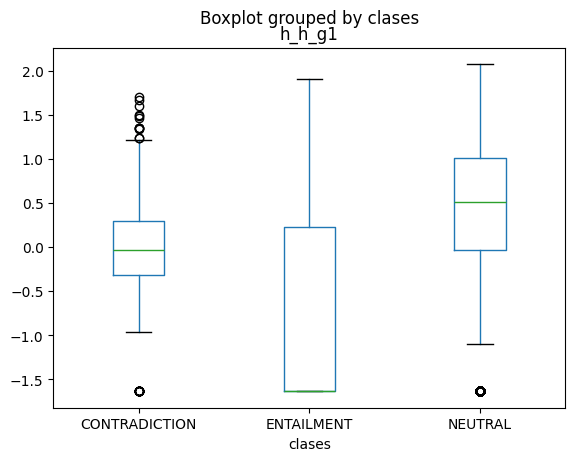

In [128]:
df_X_train.boxplot(by="clases",column=["h_h_g1"],grid=False)

In [129]:
len(df_X_train.columns)

277

# DEV

In [130]:
dev = pd.read_pickle('output/relationships/CURING_SICK/SICK_DEV_1.csv.pickle')


In [131]:
dev.columns

Index(['Texto', 'Hipotesis', 'TextoL', 'HipotesisL', 'dicEntT', 'dicEntH',
       'ConteosR', 'ConteosG1', 'ConteosG2', 'ConteosG3',
       ...
       's2', 'sinT', 'sinH', 'antT', 'antH', 'HipT', 'HipH', 'hipT', 'hipH',
       'clases'],
      dtype='object', length=301)

In [132]:
base_evidencia = (dev['C_G1'] +  dev['C_G3']*0.1) / ( 1 + (dev['C_G4']*dev['H_G4'] ) )
dev['rte'] = base_evidencia.where(dev['C_G2'] == 0, 0.0)

In [133]:
dev["H-H_G1"]=dev["H"]-dev["H_G1"]
dev["H-H_G2"]=dev["H"]-dev["H_G2"]
dev["H-H_G3"]=dev["H"]-dev["H_G3"]
dev["H-H_G4"]=dev["H"]-dev["H_G4"]
dev["H-H_G1_G2"]=dev["H"]-dev["H_G1_G2"]
dev["H-H_G1_G3"]=dev["H"]-dev["H_G1_G3"]
dev["H-H_G1_G4"]=dev["H"]-dev["H_G1_G4"]

In [134]:
dev=dev.drop(['Texto', 'Hipotesis', 'TextoL', 'HipotesisL', 'dicEntT', 'dicEntH',
       'ConteosR', 'ConteosG1', 'ConteosG2', 'ConteosG3', 'ConteosG4','ranking',
       's1','s2', 'sinT', 'sinH', 'antT', 'antH', 'HipT', 'HipH', 'hipT', 'hipH',
       'veredict','veredict_l','veredict_g1','veredict_g2','veredict_g3','veredict_g4',
       'veredict_g1S','veredict_g2S','veredict_g3S','veredict_g4S',],axis=1)

In [135]:
X_dev = np.array(dev.fillna(0).drop(['clases'],axis=1))
y_d = np.array(dev['clases'])

In [136]:
y_dev=y_d

In [137]:
scaler = preprocessing.StandardScaler().fit(X_dev)
X_scaled = scaler.transform(X_dev)
X_dev = X_scaled

In [138]:
cols_dev=dev.drop(['clases'],axis=1).columns
df_X_dev=pd.DataFrame(X_dev,columns=cols_dev)
df_X_dev["clases"]=np.array(dev['clases'])
df_X_dev

,Jaro-Winkler_rit,Jaro-Winkler_rit1,Jaro-Winkler_dsf,Jaro-Winkler_dsf1,Jaro-Winkler_rit2,Jaro-Winkler_rit21,Jaro-Winkler_rte_expert,Jaro-Winkler_rte_expert1,simBoWrel,Jaro-Winkler_ritR,...,C_G3_G4,rte,H-H_G1,H-H_G2,H-H_G3,H-H_G4,H-H_G1_G2,H-H_G1_G3,H-H_G1_G4,clases
0,-0.983544,-1.059844,0.010349,-1.115566,-0.623303,-1.340702,-0.348917,-1.371500,-0.397294,-0.899444,...,-0.977981,-0.990508,-1.359811,2.460117,-0.336765,-0.129519,1.175410,-1.668402,-1.450196,CONTRADICTION
1,-0.511088,-0.142713,-0.717052,0.325655,-0.996301,0.194736,-0.712798,0.187643,-0.108511,-0.899444,...,2.655175,-0.951341,-0.952620,-0.240188,0.330526,0.945800,-1.226777,-1.127619,-0.833192,NEUTRAL
2,-0.983544,-0.156493,-0.717052,-1.115212,-0.063805,0.677388,-0.712798,0.447828,-1.123055,-0.276358,...,1.201912,-0.234445,-0.618857,-0.240188,0.997818,-0.306999,-0.921311,0.375109,-0.677432,NEUTRAL
3,-2.755255,-1.067121,-2.353702,-1.121227,-0.623303,0.338023,-2.350259,-0.202635,-2.280962,-0.899444,...,0.838597,-0.990508,-0.741682,-0.632960,0.915053,2.292558,-0.692822,-0.743838,-0.152194,NEUTRAL
4,1.378736,0.532505,1.465150,1.245658,0.719491,1.175123,1.470484,1.182468,0.520729,0.595963,...,-0.977981,1.477005,2.021875,-0.240188,-0.336765,-0.129519,1.495538,1.487826,1.608259,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,-0.646076,-1.060713,-0.405309,0.414622,-1.182800,0.273382,-0.400900,0.283845,-0.397294,-0.899444,...,0.233071,-0.990508,-0.171615,-0.737290,-0.336765,1.185920,-0.103883,-0.559423,0.027715,NEUTRAL
491,0.433824,0.902567,0.592269,0.881700,-0.303590,0.787278,0.597171,0.788911,-0.731678,-0.543395,...,0.233071,0.736751,-0.032769,-0.240188,2.911755,-0.129519,-0.384912,1.439231,-0.249997,NEUTRAL
492,-0.983544,-0.123683,-1.262602,0.399457,-0.943015,0.273382,-1.258618,0.267447,-0.974861,-0.543395,...,2.655175,-0.905946,-0.952620,-0.240188,-0.662652,1.285099,-1.226777,-1.366860,-0.754708,NEUTRAL
493,-2.295922,-0.701594,-1.929385,-0.330142,-2.363961,-0.252723,-1.925732,-0.521489,-2.210629,-2.284080,...,0.838597,-0.020573,-0.952620,-0.240188,-0.336765,-0.129519,-1.226777,-1.288359,-0.425076,NEUTRAL


# TEST

In [139]:
test = pd.read_pickle('output/relationships/CURING_SICK/SICK_TEST_1.csv.pickle')
test

,Texto,Hipotesis,TextoL,HipotesisL,dicEntT,dicEntH,ConteosR,ConteosG1,ConteosG2,ConteosG3,...,s2,sinT,sinH,antT,antH,HipT,HipH,hipT,hipH,clases
0,there is no boy playing outdoors and there is ...,a group of kids is playing in a yard and an ol...,"[there, be, no, boy, play, outdoors, and, ther...","[a, group, of, kid, be, play, in, a, yard, and...","{'be': {}, 'boy': {'no'}, 'play': {'outdoors'}...","{'group': {'of'}, 'kid': {}, 'play': {'in', 'b...","[(outdoors play, same, play), (no man, distin...","[(outdoors play, same, play)]","[(no man, distinct_from, group), (no boy, dis...","[(yard, synonym, outdoors)]",...,"[no, group, of, kid, be, play, in, no, yard, a...","[{thither}, {cost, constitute, beryllium, bean...","[{an, o, au, type, aud, group, deoxyadenosine_...","[{}, {or_not, existing, exist, not, to, then, ...","[{}, {separate, individuals, solo, individual}...","[{their, they’re, location, thither}, {cost, c...","[{on, an, o, au, basketball_league, blood_grou...","[{therein, theremid, thereover, therefore, the...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...",NEUTRAL
1,a group of boys in a yard is playing and a man...,the young boys are playing outdoors and the ma...,"[a, group, of, boy, in, a, yard, be, play, and...","[the, young, boy, be, play, outdoors, and, the...","{'group': {'of', 'in'}, 'boy': {}, 'yard': {},...","{'young': {}, 'boy': {'young'}, 'play': {'outd...","[( boy, synonym, young), ( yard, synonym, ou...","[( boy, synonym, young), ( yard, synonym, ou...",[],"[(young boy, is_a, boy), (outdoors play, is_a...",...,"[man, young, boy, stand, play, outdoors, and, ...","[{an, o, au, type, aud, group, deoxyadenosine_...","[{ye, the}, {youth, underdeveloped, thomas_you...","[{}, {separate, individuals, solo, individual}...","[{}, {senior, mature, aged, old}, {female, sis...","[{on, an, o, au, basketball_league, blood_grou...","[{always_higher_than, 640_acres_in_square_mile...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...","[{natheless, ye, nevertheless, act_maggot, nev...",NEUTRAL
2,a group of children is playing in the house an...,the young boys are playing outdoors and the ma...,"[a, group, of, child, be, play, in, the, house...","[the, young, boy, be, play, outdoors, and, the...","{'group': {'of'}, 'child': {}, 'play': {'in', ...","{'young': {}, 'boy': {'young'}, 'play': {'outd...","[( child, synonym, young), (no man, distinct_...","[( child, synonym, young)]","[(no man, distinct_from, man)]","[(young boy, is_a, child), (outdoors play, is...",...,"[man, young, boy, stand, house, outdoors, and,...","[{an, o, au, type, aud, group, deoxyadenosine_...","[{ye, the}, {youth, underdeveloped, thomas_you...","[{}, {separate, individuals, solo, individual}...","[{}, {senior, mature, aged, old}, {female, sis...","[{on, an, o, au, basketball_league, blood_grou...","[{always_higher_than, 640_acres_in_square_mile...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...","[{natheless, ye, nevertheless, act_maggot, nev...",NEUTRAL
3,a brown dog is attacking another animal in fro...,a brown dog is attacking another animal in fro...,"[a, brown, dog, be, attack, another, animal, i...","[a, brown, dog, be, attack, another, animal, i...","{'brown': {}, 'dog': {'brown'}, 'attack': {'in...","{'brown': {}, 'dog': {'brown'}, 'attack': {'in...","[( brown, same, brown), (brown dog, same, bro...","[( brown, same, brown), (brown dog, same, bro...",[],[],...,"[a, brown, dog, be, attack, another, animal, i...","[{an, o, au, type, aud, group, deoxyadenosine_...","[{an, o, au, type, aud, group, deoxyadenosine_...","[{}, {}, {cat_again, car, bitch, cut, cat, woo...","[{}, {}, {cat_again, car, bitch, cut, cat, woo...","[{on, an, o, au, basketball_league, blood_grou...","[{on, an, o, au, basketball_league, blood_grou...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...","[{bug_boo, ahold, hedra, amnia, jack_lantern, ...",ENTAILMENT
4,a brown dog is attacking another animal in fro...,a brown dog is helping another animal in front...,"

In [140]:
test.columns

Index(['Texto', 'Hipotesis', 'TextoL', 'HipotesisL', 'dicEntT', 'dicEntH',
       'ConteosR', 'ConteosG1', 'ConteosG2', 'ConteosG3',
       ...
       's2', 'sinT', 'sinH', 'antT', 'antH', 'HipT', 'HipH', 'hipT', 'hipH',
       'clases'],
      dtype='object', length=301)

In [141]:
base_evidencia = (test['C_G1'] +  test['C_G3']*0.1) / ( 1 + (test['C_G4']*test['H_G4'] ) )
test['rte'] = base_evidencia.where(test['C_G2'] == 0, 0.0)

In [142]:
test["H-H_G1"]=test["H"]-test["H_G1"]
test["H-H_G2"]=test["H"]-test["H_G2"]
test["H-H_G3"]=test["H"]-test["H_G3"]
test["H-H_G4"]=test["H"]-test["H_G4"]
test["H-H_G1_G2"]=test["H"]-test["H_G1_G2"]
test["H-H_G1_G3"]=test["H"]-test["H_G1_G3"]
test["H-H_G1_G4"]=test["H"]-test["H_G1_G4"]

In [143]:
check=test.copy()
test=test.drop(['Texto', 'Hipotesis', 'TextoL', 'HipotesisL', 'dicEntT', 'dicEntH',
       'ConteosR', 'ConteosG1', 'ConteosG2', 'ConteosG3', 'ConteosG4','ranking',
       's1','s2', 'sinT', 'sinH', 'antT', 'antH', 'HipT', 'HipH', 'hipT', 'hipH',
       'veredict','veredict_l','veredict_g1','veredict_g2','veredict_g3','veredict_g4',
       'veredict_g1S','veredict_g2S','veredict_g3S','veredict_g4S',],axis=1)

In [144]:
X_t = np.array(test.fillna(0).drop(['clases'],axis=1))
y_t = np.array(test['clases'])

In [145]:
scaler = preprocessing.StandardScaler().fit(X_t)
X_scaled = scaler.transform(X_t)
X_test = X_scaled

In [146]:
cols_test=test.drop(['clases'],axis=1).columns
df_X_test=pd.DataFrame(X_test,columns=cols_test)
df_X_test["clases"]=np.array(test['clases'])
df_X_test

,Jaro-Winkler_rit,Jaro-Winkler_rit1,Jaro-Winkler_dsf,Jaro-Winkler_dsf1,Jaro-Winkler_rit2,Jaro-Winkler_rit21,Jaro-Winkler_rte_expert,Jaro-Winkler_rte_expert1,simBoWrel,Jaro-Winkler_ritR,...,C_G3_G4,rte,H-H_G1,H-H_G2,H-H_G3,H-H_G4,H-H_G1_G2,H-H_G1_G3,H-H_G1_G4,clases
0,-1.738423,-1.084290,-1.405517,-1.174310,-0.995336,-0.053639,-1.396078,-1.304177,-0.396766,-0.483344,...,-0.121262,-0.933726,-0.813363,3.147415,-0.438004,-0.690100,0.517875,-1.159655,-1.118378,NEUTRAL
1,-0.559908,-0.281026,-0.687656,-1.170579,-1.017301,0.293512,-0.679102,0.344008,-1.617525,-1.040266,...,1.003044,-0.030237,-0.565735,-0.307337,-0.747917,-0.367036,-0.888338,-0.508194,-0.751803,NEUTRAL
2,-0.559908,-1.081962,-0.687656,-1.174310,-1.119805,-1.292674,-0.679102,-1.304177,-1.365629,-1.169407,...,1.502735,-0.933726,-0.611995,0.204232,-0.325309,-1.187123,-0.729926,-0.724923,-1.009627,NEUTRAL
3,1.404283,1.699447,1.465929,1.322436,1.319794,1.329048,1.471825,1.312417,1.136514,1.245535,...,-0.995722,1.547309,1.486036,-0.307337,-0.359117,-0.123495,0.949243,1.006357,1.123839,ENTAILMENT
4,1.067564,1.406984,1.158274,1.257270,1.298456,1.260592,1.164550,1.244123,0.968463,1.222012,...,-0.496031,0.785633,0.096873,-0.307337,-0.359117,-0.441589,-0.294901,-0.295290,0.930777,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4901,-2.262207,-1.086018,-1.884092,-1.174262,-1.966196,-1.293765,-1.874062,-1.304127,-1.756249,-1.882912,...,1.627658,-0.933726,-0.897719,2.071127,-0.359117,0.602158,-0.749423,-1.227223,-0.838559,NEUTRAL
4902,-0.952746,-0.471720,-1.226052,-1.173759,-1.640313,0.173935,-1.216834,0.010673,-2.520456,-1.568571,...,2.502118,-0.855137,-0.897719,-0.307337,1.511627,-0.635428,-1.185665,-0.803965,-1.142816,NEUTRAL
4903,-0.690854,0.682820,-1.405517,0.320520,-0.941992,0.276523,-1.396078,0.262407,-1.794122,0.163515,...,2.502118,-0.858906,-0.897719,-0.307337,-0.747917,0.890431,-1.185665,-1.315190,-0.767688,NEUTRAL
4904,-1.738423,-1.083887,-2.482309,-0.194066,-2.517691,-0.264056,-2.471542,-0.276880,-2.636996,-2.224888,...,2.502118,-0.877613,-0.897719,-0.307337,-0.691569,0.467962,-1.185665,-1.302441,-0.871551,NEUTRAL


In [147]:
df_X_test = df_X_test[df_X_test["clases"]!=9]

# incluir clases

In [148]:
train_clases = pd.read_csv("../ska_RL/data/CURING_SICK/SICK_TRAIN_1.csv")
train_clases=train_clases[[ 'gold_label.1', 'label_kalouli', 'label_current_paper', 'Logic_label',
       'Commonsense_label', 'SICK_original', 'monalog', 'gkr4nli', 'langpro',
       'ccg2lambda_easyccg', 'ccg2lambda_candc']]

In [149]:
dev_clases = pd.read_csv("../ska_RL/data/CURING_SICK/SICK_DEV_1.csv")
dev_clases=dev_clases[[ 'gold_label.1', 'label_kalouli', 'label_current_paper', 'Logic_label',
       'Commonsense_label', 'SICK_original', 'monalog', 'gkr4nli', 'langpro',
       'ccg2lambda_easyccg', 'ccg2lambda_candc']]

In [150]:
test_clases = pd.read_csv("../ska_RL/data/CURING_SICK/SICK_TEST_1.csv")
test_clases=test_clases[[ 'gold_label.1', 'label_kalouli', 'label_current_paper', 'Logic_label',
       'Commonsense_label', 'SICK_original', 'monalog', 'gkr4nli', 'langpro',
       'ccg2lambda_easyccg', 'ccg2lambda_candc']]

In [151]:
df_X_train

,Jaro-Winkler_rit,Jaro-Winkler_rit1,Jaro-Winkler_dsf,Jaro-Winkler_dsf1,Jaro-Winkler_rit2,Jaro-Winkler_rit21,Jaro-Winkler_rte_expert,Jaro-Winkler_rte_expert1,simBoWrel,Jaro-Winkler_ritR,...,C_G3_G4,rte,H-H_G1,H-H_G2,H-H_G3,H-H_G4,H-H_G1_G2,H-H_G1_G3,H-H_G1_G4,clases
0,1.402166,0.525262,1.209851,-1.125489,1.083817,0.928564,1.213274,-1.268766,-0.716108,0.986615,...,-0.990744,1.577157,1.995116,-0.302375,-0.322998,-0.128958,1.371734,1.480015,1.549362,NEUTRAL
1,0.365270,-1.057652,0.512988,-1.127704,0.596959,-1.259863,0.518220,-1.271094,0.298594,0.451566,...,-0.990744,-0.921483,-0.868718,0.855195,-0.322998,-0.128958,1.205543,-1.185623,-0.997495,NEUTRAL
2,0.553797,0.168606,-0.477824,0.303762,-0.620186,-1.263763,-0.470021,0.233586,-1.332571,0.317804,...,0.429199,0.677646,-0.653102,-0.302375,-0.012511,-0.128958,-0.969597,1.568784,-0.805743,ENTAILMENT
3,-1.708520,-0.428846,-1.382479,0.021086,-0.421017,-0.056108,-1.372328,-0.063548,-0.312289,-0.229404,...,0.784185,-0.921483,-0.647573,-0.524467,-0.119575,0.280235,-0.708091,-0.651723,-0.868431,NEUTRAL
4,-1.449296,-1.066482,-1.382479,-1.134737,-0.985330,-1.266884,-1.372328,-1.278487,-1.158306,-0.484769,...,0.340453,-0.921483,-0.642044,0.101428,0.356862,-0.669498,-0.517461,-0.407287,-1.049120,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,-1.708520,-0.360361,-1.382479,0.194546,-0.620186,0.125748,-1.372328,0.118785,-0.865741,-0.886055,...,1.967471,-0.671800,-0.846604,-0.302375,0.865419,-1.684904,-1.140675,-0.835693,-0.992578,NEUTRAL
4435,-1.264136,-1.064968,-2.194822,-0.057843,-2.185087,-0.138857,-2.182563,-0.146513,-3.117585,-0.542095,...,2.559114,-0.838195,-0.899126,-0.302375,-0.761962,4.508567,-1.187111,-1.319419,0.103849,NEUTRAL
4436,-2.597287,-0.658517,-2.499451,-0.145338,-2.324190,-0.230586,-2.486401,-0.238483,-3.432844,-1.688627,...,1.375828,-0.430591,-0.722210,-0.302375,-0.071396,-0.543204,-1.030696,-0.906451,-1.074933,NEUTRAL
4437,-0.930849,-1.065106,-1.382479,0.136726,-2.014371,0.065129,-1.372328,0.058007,-2.093569,-1.980472,...,1.671650,-0.599327,-0.740178,-0.302375,-0.322998,1.108725,-1.046582,-1.065978,0.815543,NEUTRAL


# DATOS CON FEATURES FINALES  y MODELO DE REGRESIÓN LÓGISTICA

In [152]:
from sklearn.linear_model import LogisticRegression

In [153]:
# E1	C_G1_G3
# E2	C_G1_G4
# E3	I_G2
# E4	H-H_G1_G2
# E5	IMF
# E6	h_h_g1
# E7	T_H_G3
# E8	rte
# L9	IM_l
# L10	xIMF_G2_G4
# L11	xI_G3_G4
# L12	xTH_G2_G4
# L13	Jaro-Winkler_rit1
# L14	Jaro-Winkler_rte_expert1
# L15	Jaro-Winkler_dsf1
# L16	Jaro-Winkler_rit2
# L17	Jaro-Winkler_rit21

In [154]:
dir_new_names={'I_G2':'E3', 'C_G1_G3':'E1','C_G1_G4':'E2','h_h_g1':'E6','T_H_G3':'E7' ,
 'H-H_G1_G2': 'E4', 'IMF':'E5','IM_l':'L9', 'rte':'E8','xTH_G2_G4':'L12','xI_G3_G4':'L11',
'xIMF_G2_G4':'L10', 'Jaro-Winkler_rit1':'L13','Jaro-Winkler_rte_expert1' : 'L14', 
 'Jaro-Winkler_dsf1':'L15','Jaro-Winkler_rit2':'L16', 'Jaro-Winkler_rit21':'L17'}
dir_new_names

{'I_G2': 'E3',
 'C_G1_G3': 'E1',
 'C_G1_G4': 'E2',
 'h_h_g1': 'E6',
 'T_H_G3': 'E7',
 'H-H_G1_G2': 'E4',
 'IMF': 'E5',
 'IM_l': 'L9',
 'rte': 'E8',
 'xTH_G2_G4': 'L12',
 'xI_G3_G4': 'L11',
 'xIMF_G2_G4': 'L10',
 'Jaro-Winkler_rit1': 'L13',
 'Jaro-Winkler_rte_expert1': 'L14',
 'Jaro-Winkler_dsf1': 'L15',
 'Jaro-Winkler_rit2': 'L16',
 'Jaro-Winkler_rit21': 'L17'}

In [155]:
features_paper =['h_h_g1',
 'xIMF_G2_G4',
 'Jaro-Winkler_rit1',
 'rte',
 'IMF',
 'Jaro-Winkler_rit2',
 'C_G1_G4',
 'T_H_G3',
 'xI_G3_G4',
 'Jaro-Winkler_rte_expert1',
 'H-H_G1_G2',
 'C_G1_G3',
 'I_G2',
 'Jaro-Winkler_rit21',
 'Jaro-Winkler_dsf1',
 'IM_l',
 'xTH_G2_G4']


In [156]:
df_X_train = df_X_train[features_paper+["clases"]]
df_X_test = df_X_test[features_paper+["clases"]]
df_X_dev = df_X_dev[features_paper+["clases"]]
df_X_train

,h_h_g1,xIMF_G2_G4,Jaro-Winkler_rit1,rte,IMF,Jaro-Winkler_rit2,C_G1_G4,T_H_G3,xI_G3_G4,Jaro-Winkler_rte_expert1,H-H_G1_G2,C_G1_G3,I_G2,Jaro-Winkler_rit21,Jaro-Winkler_dsf1,IM_l,xTH_G2_G4,clases
0,-1.635564,-1.125374,0.525262,1.577157,-1.156711,1.083817,1.116124,0.748846,-0.124288,-1.268766,1.371734,1.084727,-0.421229,0.928564,-1.125489,1.133881,-0.390912,NEUTRAL
1,1.438127,0.483656,-1.057652,-0.921483,0.093879,0.596959,-0.709054,0.452903,-0.504560,-1.271094,1.205543,-0.380707,-0.415212,-1.259863,-1.127704,0.542367,0.093832,NEUTRAL
2,1.060110,-1.125374,0.168606,0.677646,1.392263,-0.620186,-0.830733,0.391974,-1.043213,0.233586,-0.969597,1.084727,-0.201302,-1.263763,0.303762,0.183646,-0.406959,ENTAILMENT
3,1.499899,0.552468,-0.428846,-0.921483,0.205397,-0.421017,-0.709054,0.198305,-0.228218,-0.063548,-0.708091,-0.380707,-0.701318,-0.056108,0.021086,-0.843656,0.454635,NEUTRAL
4,1.706269,0.596390,-1.066482,-0.921483,0.285052,-0.985330,-1.317447,0.844592,-0.745519,-1.278487,-0.517461,-0.380707,-0.765491,-1.266884,-1.134737,-1.158340,-0.752050,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,0.175108,-0.910154,-0.360361,-0.671800,0.139017,-0.620186,0.304934,-2.236694,1.954509,0.118785,-1.140675,-1.520489,-1.506750,0.125748,0.194546,-2.067034,0.551040,NEUTRAL
4435,0.449764,0.273559,-1.064968,-0.838195,-0.774365,-2.185087,-0.506257,-1.631752,-0.184240,-0.146513,-1.187111,-1.520489,-1.870695,-0.138857,-0.057843,-2.130678,-0.820456,NEUTRAL
4436,0.864913,-0.551453,-0.658517,-0.430591,-0.434502,-2.324190,0.304934,-0.447981,-1.387422,-0.238483,-1.030696,-0.869185,-1.674165,-0.230586,-0.145338,-2.430713,0.087890,NEUTRAL
4437,0.715197,-0.172255,-1.065106,-0.599327,-0.535399,-2.014371,1.116124,-0.550256,1.062355,0.058007,-1.046582,-1.846141,-1.461257,0.065129,0.136726,-1.685170,1.567217,NEUTRAL


In [157]:
df_X_train.rename(columns=dir_new_names, inplace=True)
df_X_dev.rename(columns=dir_new_names, inplace=True)
df_X_test.rename(columns=dir_new_names, inplace=True)
df_X_train

,E6,L10,L13,E8,E5,L16,E2,E7,L11,L14,E4,E1,E3,L17,L15,L9,L12,clases
0,-1.635564,-1.125374,0.525262,1.577157,-1.156711,1.083817,1.116124,0.748846,-0.124288,-1.268766,1.371734,1.084727,-0.421229,0.928564,-1.125489,1.133881,-0.390912,NEUTRAL
1,1.438127,0.483656,-1.057652,-0.921483,0.093879,0.596959,-0.709054,0.452903,-0.504560,-1.271094,1.205543,-0.380707,-0.415212,-1.259863,-1.127704,0.542367,0.093832,NEUTRAL
2,1.060110,-1.125374,0.168606,0.677646,1.392263,-0.620186,-0.830733,0.391974,-1.043213,0.233586,-0.969597,1.084727,-0.201302,-1.263763,0.303762,0.183646,-0.406959,ENTAILMENT
3,1.499899,0.552468,-0.428846,-0.921483,0.205397,-0.421017,-0.709054,0.198305,-0.228218,-0.063548,-0.708091,-0.380707,-0.701318,-0.056108,0.021086,-0.843656,0.454635,NEUTRAL
4,1.706269,0.596390,-1.066482,-0.921483,0.285052,-0.985330,-1.317447,0.844592,-0.745519,-1.278487,-0.517461,-0.380707,-0.765491,-1.266884,-1.134737,-1.158340,-0.752050,NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,0.175108,-0.910154,-0.360361,-0.671800,0.139017,-0.620186,0.304934,-2.236694,1.954509,0.118785,-1.140675,-1.520489,-1.506750,0.125748,0.194546,-2.067034,0.551040,NEUTRAL
4435,0.449764,0.273559,-1.064968,-0.838195,-0.774365,-2.185087,-0.506257,-1.631752,-0.184240,-0.146513,-1.187111,-1.520489,-1.870695,-0.138857,-0.057843,-2.130678,-0.820456,NEUTRAL
4436,0.864913,-0.551453,-0.658517,-0.430591,-0.434502,-2.324190,0.304934,-0.447981,-1.387422,-0.238483,-1.030696,-0.869185,-1.674165,-0.230586,-0.145338,-2.430713,0.087890,NEUTRAL
4437,0.715197,-0.172255,-1.065106,-0.599327,-0.535399,-2.014371,1.116124,-0.550256,1.062355,0.058007,-1.046582,-1.846141,-1.461257,0.065129,0.136726,-1.685170,1.567217,NEUTRAL


In [158]:
features_paper=df_X_train.columns.to_list()[:-1]

# SICK

In [159]:
data_test =  data_test[data_test["clases"]!=9]
model_full_sick = LogisticRegression(penalty="l2", C=1,max_iter=10000)
model_full_sick.fit(data_train.drop(columns=["clases"]), data_train['clases'] )
data_dev_test=pd.concat([data_dev,data_test],axis=0)
#DEV
#predictions_CEN = model_full_sick.predict(data_dev.drop(columns=["clases"]))
#print( classification_report(data_dev['clases'], predictions_CEN,digits=3) )
#print( confusion_matrix(data_dev['clases'], predictions_CEN) )
#TEST
predictions_CEN = model_full_sick.predict(data_test.drop(columns=["clases"]))
print( classification_report(data_test['clases'], predictions_CEN,digits=3) )
#print( confusion_matrix(data_test['clases'], predictions_CEN) )
#TEST
#predictions_CEN = model_full_sick.predict(data_dev_test.drop(columns=["clases"]))
#print( classification_report(data_dev_test['clases'], predictions_CEN,digits=3) )
#print( confusion_matrix(data_dev_test['clases'], predictions_CEN) )

               precision    recall  f1-score   support

CONTRADICTION      0.850     0.778     0.812       712
   ENTAILMENT      0.775     0.791     0.783      1404
      NEUTRAL      0.849     0.859     0.854      2789

     accuracy                          0.828      4905
    macro avg      0.825     0.809     0.816      4905
 weighted avg      0.828     0.828     0.827      4905



/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [160]:
data_train['clases']

0          NEUTRAL
1          NEUTRAL
2       ENTAILMENT
3          NEUTRAL
4          NEUTRAL
           ...    
4434       NEUTRAL
4435       NEUTRAL
4436       NEUTRAL
4437       NEUTRAL
4438       NEUTRAL
Name: clases, Length: 4439, dtype: str

# 3 classes

In [161]:
new_dataCEN = {'feature':[],'accuracy':[],
            'precision_E':[],'recall_E':[],'f1_E':[],'support_E':[],
            'precision_N':[],'recall_N':[],'f1_N':[],'support_N':[],
            'precision_C':[],'recall_C':[],'f1_C':[],'support_C':[],
            'macro_avg_P':[],'macro_avg_R':[],'macro_avg_f1':[],'macro_avg_S':[],
            'weighted_avg_P':[],'weighted_avg_R':[],'weighted_avg_f1':[],'weighted_avg_S':[],
            'matrix_c':[]
            }

In [162]:
data_test =  data_test[data_test["clases"]!=9]
for f_ in features_paper:
    model_full = LogisticRegression(penalty="l2", C=1,max_iter=10000)
    model_full.fit(data_train[[f_]].values, data_train['clases'] )
    #TEST
    predictions_CEN = model_full.predict(data_test[[f_]].values)
    print("feature",f_)
    dir_results= classification_report(data_test['clases'], predictions_CEN,digits=3,output_dict=True)
    new_dataCEN["matrix_c"].append(confusion_matrix(data_test['clases'], predictions_CEN))    
    new_dataCEN["accuracy"].append(dir_results['accuracy'])
    new_dataCEN["feature"].append(f_)
    new_dataCEN["precision_C"].append(dir_results['CONTRADICTION']['precision'])
    new_dataCEN["recall_C"].append(dir_results['CONTRADICTION']['recall'])
    new_dataCEN["f1_C"].append(dir_results['CONTRADICTION']['f1-score'])
    new_dataCEN["support_C"].append(dir_results['CONTRADICTION']['support'])
    new_dataCEN["precision_N"].append(dir_results['NEUTRAL']['precision'])
    new_dataCEN["recall_N"].append(dir_results['NEUTRAL']['recall'])
    new_dataCEN["f1_N"].append(dir_results['NEUTRAL']['f1-score'])
    new_dataCEN["support_N"].append(dir_results['NEUTRAL']['support'])
    new_dataCEN["precision_E"].append(dir_results['ENTAILMENT']['precision'])
    new_dataCEN["recall_E"].append(dir_results['ENTAILMENT']['recall'])
    new_dataCEN["f1_E"].append(dir_results['ENTAILMENT']['f1-score'])
    new_dataCEN["support_E"].append(dir_results['ENTAILMENT']['support'])
    new_dataCEN["macro_avg_P"].append(dir_results['macro avg']['precision'])
    new_dataCEN["macro_avg_R"].append(dir_results['macro avg']['recall'])
    new_dataCEN["macro_avg_f1"].append(dir_results['macro avg']['f1-score'])
    new_dataCEN["macro_avg_S"].append(dir_results['macro avg']['support'])
    new_dataCEN["weighted_avg_P"].append(dir_results['weighted avg']['precision'])
    new_dataCEN["weighted_avg_R"].append(dir_results['weighted avg']['recall'])
    new_dataCEN["weighted_avg_f1"].append(dir_results['weighted avg']['f1-score'])
    new_dataCEN["weighted_avg_S"].append(dir_results['weighted avg']['support'])
    

/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


feature E6
feature L10
feature L13


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='

feature E8


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

feature E5
feature L16
feature E2


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

feature E7


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

feature L11
feature L14
feature E4
feature E1


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='

feature E3
feature L17
feature L15
feature L9


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

feature L12


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [163]:
results_new_dataCEN = pd.DataFrame(new_dataCEN)
results_new_dataCEN.sort_values("accuracy",ascending=False)

,feature,accuracy,precision_E,recall_E,f1_E,support_E,precision_N,recall_N,f1_N,support_N,...,support_C,macro_avg_P,macro_avg_R,macro_avg_f1,macro_avg_S,weighted_avg_P,weighted_avg_R,weighted_avg_f1,weighted_avg_S,matrix_c
1,L10,0.746585,0.686856,0.807692,0.742390,1404.0,0.779098,0.799211,0.789027,2789.0,...,712.0,0.742256,0.675616,0.690864,4905.0,0.750041,0.746585,0.739700,4905.0,"[[299, 31, 382], [20, 1134, 250], [74, 486, 22..."
3,E8,0.716208,0.730412,0.783476,0.756014,1404.0,0.709915,0.865185,0.779897,2789.0,...,712.0,0.480109,0.549553,0.511970,4905.0,0.612732,0.716208,0.659852,4905.0,"[[0, 30, 682], [0, 1100, 304], [0, 376, 2413]]"
11,E1,0.704587,0.694053,0.806268,0.745964,1404.0,0.709835,0.833274,0.766617,2789.0,...,712.0,0.467963,0.546514,0.504194,4905.0,0.602279,0.704587,0.649425,4905.0,"[[0, 34, 678], [0, 1132, 272], [0, 465, 2324]]"
0,E6,0.682977,0.692939,0.601140,0.643783,1404.0,0.679685,0.898530,0.773935,2789.0,...,712.0,0.457542,0.499890,0.472573,4905.0,0.584817,0.682977,0.624337,4905.0,"[[0, 91, 621], [0, 844, 560], [0, 283, 2506]]"
15,L9,0.677064,0.539307,0.698718,0.608750,1404.0,0.758263,0.839010,0.796596,2789.0,...,712.0,0.432523,0.512576,0.468448,4905.0,0.585522,0.677064,0.627195,4905.0,"[[0, 389, 323], [0, 981, 423], [0, 449, 2340]]"
9,L14,0.673802,0.703856,0.611111,0.654213,1404.0,0.663863,0.877375,0.755830,2789.0,...,712.0,0.455906,0.496162,0.470014,4905.0,0.578946,0.673802,0.617029,4905.0,"[[0, 19, 693], [0, 858, 546], [0, 342, 2447]]"
13,L17,0.671967,0.704603,0.599715,0.647942,1404.0,0.661456,0.879885,0.755193,2789.0,...,712.0,0.455353,0.493200,0.467712,4905.0,0.577790,0.671967,0.614871,4905.0,"[[0, 18, 694], [0, 842, 562], [0, 335, 2454]]"
4,E5,0.665240,0.667436,0.617521,0.641509,1404.0,0.664724,0.858731,0.749374,2789.0,...,712.0,0.555165,0.492552,0.464560,4905.0,0.617396,0.665240,0.610128,4905.0,"[[1, 40, 671], [0, 867, 537], [2, 392, 2395]]"
2,L13,0.649134,0.663462,0.540598,0.595761,1404.0,0.644775,0.869487,0.740458,2789.0,...,712.0,0.436079,0.470029,0.445406,4905.0,0.556530,0.649134,0.591557,4905.0,"[[0, 21, 691], [0, 759, 645], [0, 364, 2425]]"
14,L15,0.632620,0.716396,0.345442,0.466122,1404.0,0.619205,0.938688,0.746188,2789.0,...,712.0,0.445200,0.428043,0.404103,4905.0,0.557142,0.632620,0.557707,4905.0,"[[0, 21, 691], [0, 485, 919], [0, 171, 2618]]"


# 2 etiquetas

In [164]:
#m_C_E = LogisticRegression(penalty="l2", C=1,max_iter=10000)
m_C_E = LogisticRegression(max_iter=10000)
df_X_train_C_E = df_X_train[df_X_train['clases'] != 'NEUTRAL']
m_C_E.fit(df_X_train_C_E[features_paper], df_X_train_C_E['clases'] )
df_X_test_C_E = df_X_test[df_X_test['clases'] != 'NEUTRAL']
pred_CE = m_C_E.predict(df_X_test_C_E[features_paper])
print( classification_report(df_X_test_C_E['clases'], pred_CE,digits=3) ) 
print( confusion_matrix(df_X_test_C_E['clases'], pred_CE) )
#
df_X_test_C_E = data_dev_test[data_dev_test['clases'] != 'NEUTRAL']
pred_CE = m_C_E.predict(df_X_test_C_E[features_paper])
print( classification_report(df_X_test_C_E['clases'], pred_CE,digits=3) ) 
print( confusion_matrix(df_X_test_C_E['clases'], pred_CE) )

               precision    recall  f1-score   support

CONTRADICTION      0.956     0.919     0.937       712
   ENTAILMENT      0.959     0.979     0.969      1404

     accuracy                          0.958      2116
    macro avg      0.958     0.949     0.953      2116
 weighted avg      0.958     0.958     0.958      2116

[[ 654   58]
 [  30 1374]]
               precision    recall  f1-score   support

CONTRADICTION      0.950     0.920     0.934       783
   ENTAILMENT      0.960     0.975     0.968      1547

     accuracy                          0.957      2330
    macro avg      0.955     0.947     0.951      2330
 weighted avg      0.957     0.957     0.956      2330

[[ 720   63]
 [  38 1509]]


In [165]:
new_dataCE = {'feature':[],'accuracy':[],
            'precision_E':[],'recall_E':[],'f1_E':[],'support_E':[],
            'precision_C':[],'recall_C':[],'f1_C':[],'support_C':[],
            'macro_avg_P':[],'macro_avg_R':[],'macro_avg_f1':[],'macro_avg_S':[],
            'weighted_avg_P':[],'weighted_avg_R':[],'weighted_avg_f1':[],'weighted_avg_S':[],
            'matrix_c':[]
            }

In [166]:
df_X_train_C_E = df_X_train[df_X_train['clases'] != 'NEUTRAL']
df_X_test_C_E = df_X_test[df_X_test['clases'] != 'NEUTRAL']
for f_ in features_paper:
    m_C_E = LogisticRegression(max_iter=10000)
    m_C_E.fit(df_X_train_C_E[[f_]], df_X_train_C_E['clases'] )
    pred_CE = m_C_E.predict(df_X_test_C_E[[f_]])
    print("feature",f_)
    dir_results= classification_report(df_X_test_C_E['clases'], pred_CE,digits=3,output_dict=True)
    new_dataCE["matrix_c"].append(confusion_matrix(data_test['clases'], predictions_CEN))    
    new_dataCE["accuracy"].append(dir_results['accuracy'])
    new_dataCE["feature"].append(f_)
    new_dataCE["precision_C"].append(dir_results['CONTRADICTION']['precision'])
    new_dataCE["recall_C"].append(dir_results['CONTRADICTION']['recall'])
    new_dataCE["f1_C"].append(dir_results['CONTRADICTION']['f1-score'])
    new_dataCE["support_C"].append(dir_results['CONTRADICTION']['support'])
    new_dataCE["precision_E"].append(dir_results['ENTAILMENT']['precision'])
    new_dataCE["recall_E"].append(dir_results['ENTAILMENT']['recall'])
    new_dataCE["f1_E"].append(dir_results['ENTAILMENT']['f1-score'])
    new_dataCE["support_E"].append(dir_results['ENTAILMENT']['support'])
    new_dataCE["macro_avg_P"].append(dir_results['macro avg']['precision'])
    new_dataCE["macro_avg_R"].append(dir_results['macro avg']['recall'])
    new_dataCE["macro_avg_f1"].append(dir_results['macro avg']['f1-score'])
    new_dataCE["macro_avg_S"].append(dir_results['macro avg']['support'])
    new_dataCE["weighted_avg_P"].append(dir_results['weighted avg']['precision'])
    new_dataCE["weighted_avg_R"].append(dir_results['weighted avg']['recall'])
    new_dataCE["weighted_avg_f1"].append(dir_results['weighted avg']['f1-score'])
    new_dataCE["weighted_avg_S"].append(dir_results['weighted avg']['support'])
    

feature E6


feature L10
feature L13
feature E8
feature E5
feature L16
feature E2
feature E7
feature L11
feature L14
feature E4
feature E1
feature E3
feature L17


/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

feature L15
feature L9
feature L12


In [167]:
resultsnew_dataCE = pd.DataFrame(new_dataCE)


In [168]:
resultsnew_dataCE.sort_values("accuracy",ascending=False).head(5).to_csv("resultados_SICK_CE_features.csv",index=False)

In [169]:
results_new_dataCEN.sort_values("accuracy",ascending=False).head(5).to_csv("resultados_SICK_completo_features.csv",index=False)

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def generar_graficas_rendimiento(file_ce, file_completo):
    # 1. Cargar los datos
    df_ce = pd.read_csv(file_ce)
    df_completo = pd.read_csv(file_completo)

    # 2. Seleccionar las top 5 por Macro F1 (la métrica más robusta)
    top_5_ce = df_ce.sort_values(by='macro_avg_f1', ascending=False).head(5)
    top_5_completo = df_completo.sort_values(by='macro_avg_f1', ascending=False).head(5)

    datasets = [
        (top_5_ce, 'SICK CE (Binario)', 'comparacion_sick_ce.png'),
        (top_5_completo, 'SICK Completo (Multiclase)', 'comparacion_sick_completo.png')
    ]

    for df, title, filename in datasets:
        # Configuración de los datos
        features = df['feature'].tolist()
        accuracy = df['accuracy'].tolist()
        macro_f1 = df['macro_avg_f1'].tolist()

        x = np.arange(len(features))
        width = 0.35  # Ancho de las barras

        fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
        
        # Crear barras agrupadas
        rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#AED6F1', edgecolor='black', linewidth=0.5)
        rects2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1', color='#2E86C1', edgecolor='black', linewidth=0.5)

        # Personalización estética
        ax.set_ylabel('Performance', fontsize=12)
        #ax.set_title(f'Top 5 Features: {title}', fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(features, rotation=20, ha='right', fontsize=10)
        ax.set_ylim(0, 1.1)  # Espacio para la leyenda
        ax.legend(frameon=True, loc='upper right')
        
        # Añadir cuadrícula ligera
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax.set_axisbelow(True)

        # Añadir etiquetas de valor sobre las barras (opcional)
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), 
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9)

        autolabel(rects1)
        autolabel(rects2)

        plt.tight_layout()
        plt.savefig(filename)
        print(f"Gráfica guardada como: {filename}")
        plt.close()

# Ejecutar la función con tus archivos
generar_graficas_rendimiento('resultados_SICK_CE_features.csv', 'resultados_SICK_completo_features.csv')

Gráfica guardada como: comparacion_sick_ce.png
Gráfica guardada como: comparacion_sick_completo.png


# Validación cruzada

In [203]:
df_X_CV = pd.concat([df_X_test],axis=0)
df_Y_CV = df_X_CV["clases"]

In [204]:
validation_size = 0.2
X_train_cv, X_validation_cv, Y_train_cv, Y_validation_cv = model_selection.train_test_split(df_X_CV.drop(columns=["clases"]), df_Y_CV, test_size=validation_size)

In [205]:
from sklearn.metrics import make_scorer,precision_score

In [206]:
Y_train_cv.map({"NEUTRAL":2,"CONTRADICTION":0,"ENTAILMENT":1})

625     1
4011    1
2147    1
678     1
314     1
       ..
3265    2
2279    2
1116    1
1157    2
4868    2
Name: clases, Length: 3924, dtype: int64

In [207]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=5)
cv_results = model_selection.cross_val_score(model_full_sick, X_train_cv, Y_train_cv.map({"NEUTRAL":2,"CONTRADICTION":0,"ENTAILMENT":1}), cv=kfold, scoring='accuracy')
msg = "%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
print(cv_results)
print(msg)

/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

[0.83694268 0.81528662 0.84458599 0.83566879 0.80739796]
Logistic Regression: 0.830000 (0.014142)


In [208]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=5)
scoring = make_scorer(precision_score, zero_division=0)
cv_results = model_selection.cross_val_score(model_full_sick, X_train_cv, Y_train_cv, cv=kfold, scoring="precision_weighted")
msg = "%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
cv_results = model_selection.cross_val_score(model_full_sick, X_train_cv, Y_train_cv, cv=kfold, scoring='recall_weighted')
msg += "\n%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
cv_results = model_selection.cross_val_score(model_full_sick, X_train_cv, Y_train_cv, cv=kfold, scoring='f1_weighted')
msg += "\n%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
print(msg)

/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

Logistic Regression: 0.830000 (0.013818)
Logistic Regression: 0.830000 (0.014142)
Logistic Regression: 0.830000 (0.013997)


In [209]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=5)
cv_results = model_selection.cross_val_score(model_full_sick, X_train_cv, Y_train_cv, cv=kfold, scoring='matthews_corrcoef')
msg = "%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
print(msg)

/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

Logistic Regression: 0.700000 (0.024685)


## validación cruzada SICK CE

In [210]:
df_X_dev_C_E =df_X_dev[df_X_dev["clases"] != "NEUTRAL"].copy()

In [211]:
df_X_CV_CE = pd.concat([df_X_test_C_E, df_X_dev_C_E],axis=0)
df_Y_CV_CE = df_X_CV_CE["clases"].map({"ENTAILMENT":1,"CONTRADICTION":0})

In [212]:
validation_size = 0.2
X_train_cv_C_E, X_validation_cv_C_E, Y_train_cv_C_E, Y_validation_cv_C_E = model_selection.train_test_split(df_X_CV_CE.drop(columns=["clases"]), df_Y_CV_CE, test_size=validation_size)

In [216]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=5)
cv_results = model_selection.cross_val_score(m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring='accuracy')
msg = "%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
print(msg)

Logistic Regression: 0.960000 (0.006404)


In [217]:
name='Logistic Regression'
kfold = model_selection.KFold(n_splits=5)
scoring = make_scorer(precision_score, zero_division=0)
cv_results = model_selection.cross_val_score(m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring='precision')
msg = "%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
cv_results = model_selection.cross_val_score(m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring='recall')
msg += "\n%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
cv_results = model_selection.cross_val_score(m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring='f1')
msg += "\n%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())
print(msg)

Logistic Regression: 0.960000 (0.009146)
Logistic Regression: 0.970000 (0.008790)
Logistic Regression: 0.970000 (0.004807)


In [218]:
name = 'Logistic Regression'
kfold = model_selection.KFold(n_splits=5)

# Especificar que la clase positiva es 'ENTAILMENT' (o la que corresponda)
precision = make_scorer(precision_score,  zero_division=0)
recall = make_scorer(recall_score, )
f1 = make_scorer(f1_score, )

cv_results = model_selection.cross_val_score(
    m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring=precision
)
msg = "%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())

cv_results = model_selection.cross_val_score(
    m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring=recall
)
msg += "\n%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())

cv_results = model_selection.cross_val_score(
    m_C_E, X_train_cv_C_E, Y_train_cv_C_E, cv=kfold, scoring=f1
)
msg += "\n%s: %f (%f)" % (name, round(cv_results.mean(),2), cv_results.std())

In [219]:
msg

'Logistic Regression: 0.960000 (0.009146)\nLogistic Regression: 0.970000 (0.008790)\nLogistic Regression: 0.970000 (0.004807)'

# Shap Values

In [220]:
import shap
import pandas as pd
import numpy as np
shap.initjs()

/home/david/anaconda3/envs/rit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [221]:
model = linear_model.LogisticRegression().fit(df_X_train.drop(columns=["clases"]),df_X_train["clases"].map({"CONTRADICTION":0,"ENTAILMENT":1,"NEUTRAL":2}))

In [222]:
model.classes_

array([0, 1, 2])

In [223]:
explainer = shap.LinearExplainer(model,df_X_train.drop(columns=["clases"]))

In [224]:
shap_values = explainer.shap_values(df_X_train.drop(columns=["clases"]))

In [225]:
shap_values[1]

array([[-2.13501831e-01,  5.34738385e-02,  1.60027993e-01],
       [ 1.65546440e-01, -1.15078319e-01, -5.04681205e-02],
       [ 5.06077872e-01, -2.94476628e-01, -2.11601244e-01],
       [ 4.60340425e-01, -4.98100079e-01,  3.77596543e-02],
       [ 3.67912656e-04,  4.45387653e-04, -8.13300309e-04],
       [ 2.26869987e-01, -1.18033846e-01, -1.08836141e-01],
       [-3.54044880e-01,  8.49426224e-03,  3.45550618e-01],
       [-1.35598336e-01,  5.09374324e-02,  8.46609039e-02],
       [ 1.87679791e-01,  2.14506599e-02, -2.09130451e-01],
       [-2.28175793e-01, -1.99992756e-01,  4.28168549e-01],
       [ 1.10858666e-01, -7.31966478e-02, -3.76620177e-02],
       [-1.23419037e-01,  1.96839099e-02,  1.03735127e-01],
       [-3.95556327e-01,  5.00530145e-02,  3.45503313e-01],
       [ 8.07871673e-01, -3.81546395e-01, -4.26325279e-01],
       [ 6.69972344e-01, -2.78446691e-01, -3.91525652e-01],
       [-1.09985063e-01,  2.83283166e-01, -1.73298103e-01],
       [-2.23195335e-03,  2.57582788e-03

In [226]:
print(np.shape(shap_values))

(4439, 17, 3)


In [227]:
mis_clases = ['CONTRADICTION','ENTAILMENT', 'NEUTRAL']

In [228]:
dir_new_names={'I_G2':'E3', 'C_G1_G3':'E1','C_G1_G4':'E2','h_h_g1':'E6','T_H_G3':'E7' ,
 'H-H_G1_G2': 'E4', 'IMF':'E5','IM_l':'L9', 'rte':'E8','xTH_G2_G4':'L12','xI_G3_G4':'L11',
'xIMF_G2_G4':'L10', 'Jaro-Winkler_rit1':'L13','Jaro-Winkler_rte_expert1' : 'L14', 
 'Jaro-Winkler_dsf1':'L15','Jaro-Winkler_rit2':'L16', 'Jaro-Winkler_rit21':'L17'}
dir_new_names
#df_X_train_C_E.rename(columns=dir_new_names, inplace=True)

{'I_G2': 'E3',
 'C_G1_G3': 'E1',
 'C_G1_G4': 'E2',
 'h_h_g1': 'E6',
 'T_H_G3': 'E7',
 'H-H_G1_G2': 'E4',
 'IMF': 'E5',
 'IM_l': 'L9',
 'rte': 'E8',
 'xTH_G2_G4': 'L12',
 'xI_G3_G4': 'L11',
 'xIMF_G2_G4': 'L10',
 'Jaro-Winkler_rit1': 'L13',
 'Jaro-Winkler_rte_expert1': 'L14',
 'Jaro-Winkler_dsf1': 'L15',
 'Jaro-Winkler_rit2': 'L16',
 'Jaro-Winkler_rit21': 'L17'}

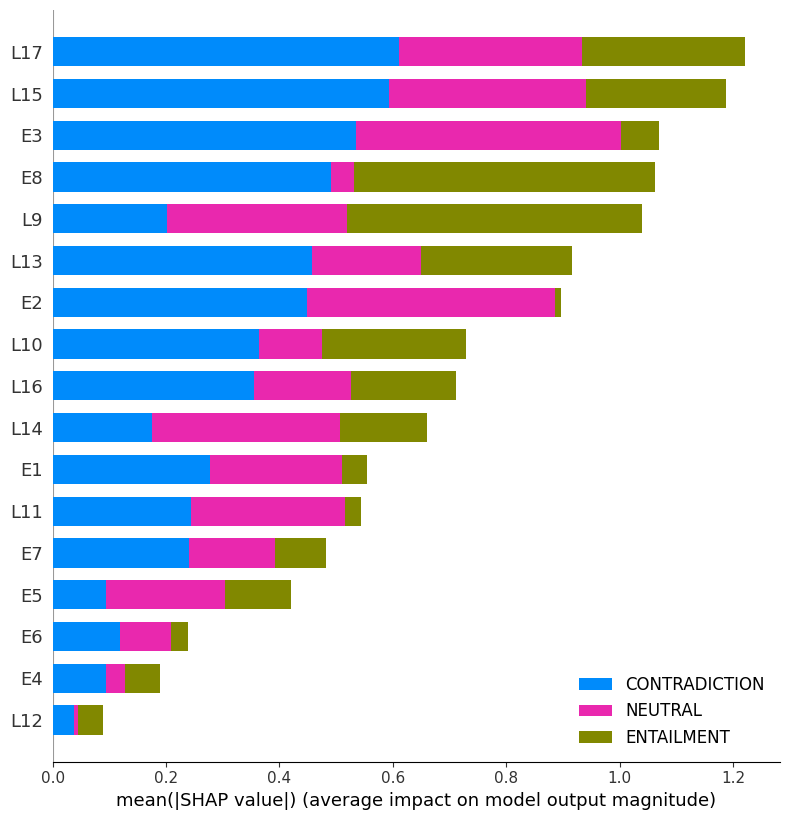

In [229]:
shap.summary_plot(shap_values, df_X_train.rename(columns=dir_new_names).drop(columns=["clases"]), plot_type="bar", class_names=mis_clases)

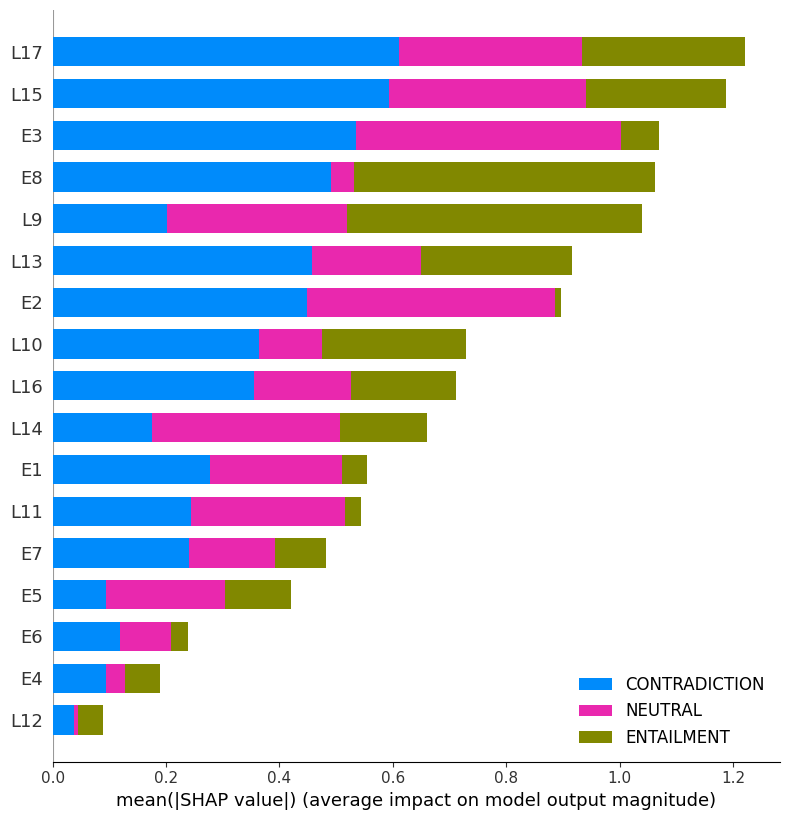

In [230]:
shap.summary_plot(shap_values, df_X_train.rename(columns=dir_new_names).drop(columns=["clases"]), plot_type="bar", class_names=mis_clases)

In [ ]:
import numpy as np

shap_values_fixed = [s.T for s in shap_values] 

# COMPROBACIÓN FINAL (Debe salir (4905, 17))
print("Forma corregida:", np.array(shap_values_fixed[0]).shape)

Forma corregida: (3, 17)


In [232]:
import pandas as pd
import numpy as np

# Calculamos el promedio absoluto por cada clase
# shap_values_fixed es la lista de matrices (4339, 17) que ya tienes
mean_shaps = [np.abs(s).mean(0) for s in shap_values_fixed]

# Creamos el DataFrame para la tabla
df_importancia = pd.DataFrame({
    'Feature': df_X_train.drop(columns=["clases"]).columns,
    'Entailment': mean_shaps[1],
    'Contradiction': mean_shaps[0],
    'Neutral': mean_shaps[2]
})

# Calculamos el total global para ordenar
df_importancia['Global'] = df_importancia[['Entailment', 'Contradiction', 'Neutral']].sum(axis=1)
df_importancia = df_importancia.sort_values(by='Global', ascending=False)

print(df_importancia)

   Feature  Entailment  Contradiction   Neutral    Global
13     L17    0.538581       0.435126  0.540316  1.514023
3       E8    0.332067       0.666077  0.306745  1.304888
14     L15    0.446648       0.445721  0.152777  1.045146
6       E2    0.236030       0.448318  0.281653  0.966001
1      L10    0.110364       0.336198  0.336198  0.782761
12      E3    0.263704       0.266327  0.170451  0.700482
2      L13    0.337385       0.226233  0.099240  0.662858
15      L9    0.188855       0.433416  0.040543  0.662814
9      L14    0.285446       0.284888  0.074961  0.645295
5      L16    0.151247       0.286841  0.187739  0.625827
11      E1    0.082279       0.249786  0.249786  0.581851
8      L11    0.139420       0.051156  0.264446  0.455022
4       E5    0.000542       0.210197  0.219335  0.430073
0       E6    0.142335       0.153827  0.105911  0.402073
7       E7    0.090399       0.152838  0.077544  0.320781
10      E4    0.073906       0.085252  0.074600  0.233758
16     L12    

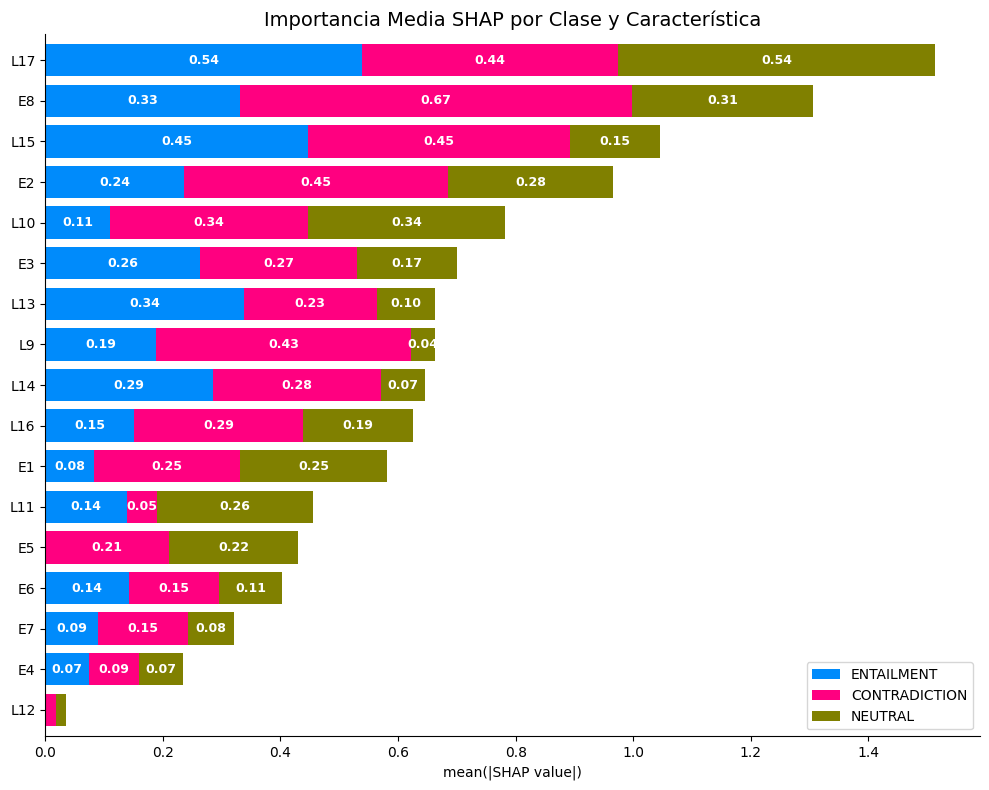

In [233]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Preparar los datos (usando tus matrices de 4339x17)
features = df_X_train.rename(columns=dir_new_names).drop(columns=["clases"]).columns
# Calculamos el promedio del valor absoluto para cada clase
importancia_clases = {
    'ENTAILMENT': np.abs(shap_values_fixed[1]).mean(0),
    'CONTRADICTION': np.abs(shap_values_fixed[0]).mean(0),
    'NEUTRAL': np.abs(shap_values_fixed[2]).mean(0)
}

df_plot = pd.DataFrame(importancia_clases, index=features)
df_plot['Total'] = df_plot.sum(axis=1)
df_plot = df_plot.sort_values('Total', ascending=True) # Ordenar para el gráfico

# 2. Graficar
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#008bfb', '#ff0080', '#808000'] # Colores de tu imagen features.png

# Graficar barras apiladas
df_plot[['ENTAILMENT', 'CONTRADICTION', 'NEUTRAL']].plot(
    kind='barh', stacked=True, color=colors, ax=ax, width=0.8
)

# 3. AGREGAR LOS VALORES NUMÉRICOS
for p in ax.patches:
    width = p.get_width()
    if width > 0.03: # Solo poner el número si la barra es lo suficientemente grande
        ax.text(p.get_x() + width/2, 
                p.get_y() + p.get_height()/2, 
                f'{width:.2f}', 
                va='center', ha='center', color='white', fontsize=9, fontweight='bold')

# 4. Formato final para el paper
ax.set_title('Importancia Media SHAP por Clase y Característica', fontsize=14)
ax.set_xlabel('mean(|SHAP value|)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

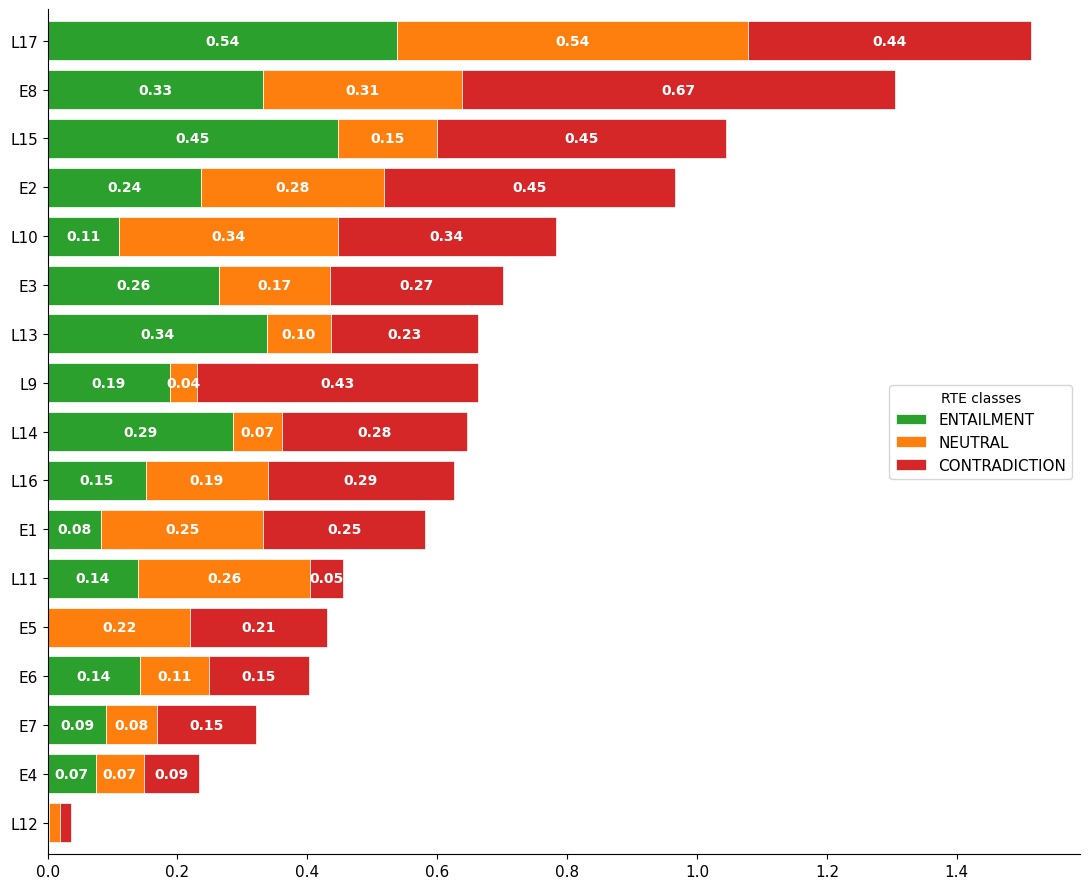

In [234]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Preparar los datos
features = df_X_train.rename(columns=dir_new_names).drop(columns=["clases"]).columns
importancia_clases = {
    'ENTAILMENT': np.abs(shap_values_fixed[1]).mean(0),
    'NEUTRAL': np.abs(shap_values_fixed[2]).mean(0), # Movido para el orden de la leyenda
    'CONTRADICTION': np.abs(shap_values_fixed[0]).mean(0)
}

df_plot = pd.DataFrame(importancia_clases, index=features)
df_plot['Total'] = df_plot.sum(axis=1)
df_plot = df_plot.sort_values('Total', ascending=True)

# 2. Definir tus nuevos colores
# Verde para Entailment, Naranja para Neutral, Rojo para Contradiction
colores_paper = ['#2ca02c', '#ff7f0e', '#d62728'] 

# 3. Graficar
fig, ax = plt.subplots(figsize=(11, 9))

# Graficamos manteniendo el orden de tus colores
df_plot[['ENTAILMENT', 'NEUTRAL', 'CONTRADICTION']].plot(
    kind='barh', 
    stacked=True, 
    color=colores_paper, 
    ax=ax, 
    width=0.8,
    edgecolor='white', # Añade una pequeña separación entre bloques para mayor claridad
    linewidth=0.5
)

# 4. Agregar los valores numéricos dentro de las barras
for p in ax.patches:
    width = p.get_width()
    if width > 0.04: # Solo anotamos si hay espacio suficiente
        ax.text(p.get_x() + width/2, 
                p.get_y() + p.get_height()/2, 
                f'{width:.2f}', 
                va='center', ha='center', 
                color='white', fontsize=10, fontweight='bold')

# 5. Formato para publicación (Computational Linguistics style)
#ax.set_title('Distribución de Importancia SHAP por Categoría Semántica', fontsize=15, pad=20)
#ax.set_xlabel('mean(|SHAP value|) - Impacto promedio en el modelo', fontsize=12)
#ax.set_ylabel('Características (Grupos Semánticos y Métricas)', fontsize=12)

# Limpiar el diseño
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=11)

plt.legend(title='RTE classes', loc='center right', fontsize=11)
plt.tight_layout()

# Guardar para el paper con alta resolución
# plt.savefig('importancia_final_nli.png', dpi=300, bbox_inches='tight')
plt.show()

In [235]:
len(shap_values)

4439

In [236]:
import numpy as np

# Convertimos a un array de numpy para manipular dimensiones
# Si shap_values tiene forma (4339, 17, 3)
shap_array = np.array(shap_values)

# Extraemos la Clase 0 (Entailment)
# Buscamos que el resultado sea (4339, 17)
shap_entailment = shap_array[:, :, 0] 

print("Forma para la gráfica:", shap_entailment.shape) 
# Debería mostrar (4339, 17)

Forma para la gráfica: (4439, 17)


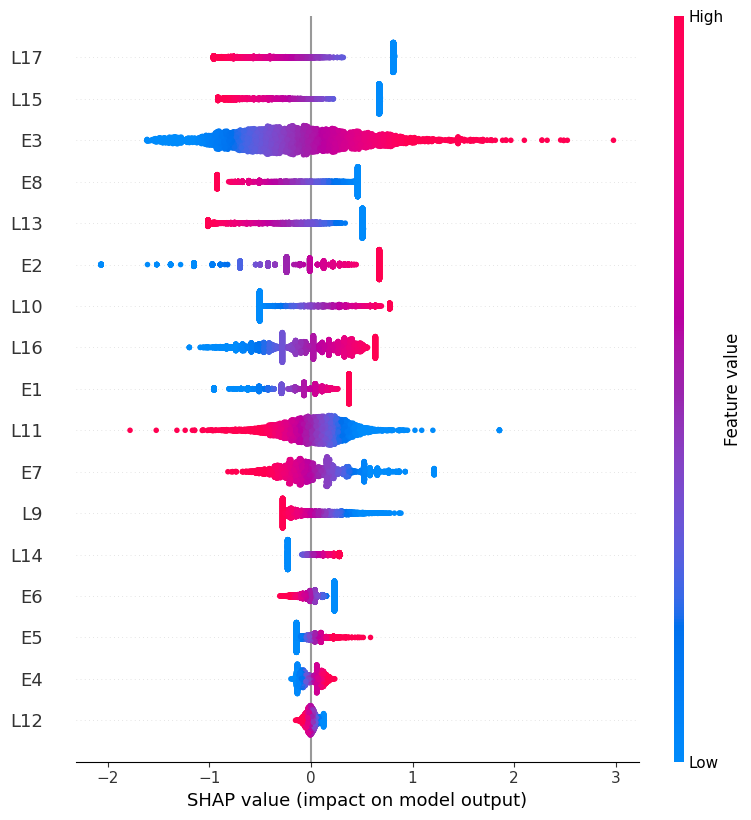

In [238]:
# Resumen de dispersión para Entailment
shap.summary_plot(shap_entailment, df_X_train.drop(columns=["clases"]))

In [241]:
shap_values

array([[[ 2.30740707e-01, -5.77915010e-02, -1.72949206e-01],
        [-5.04297413e-01,  3.50558422e-01,  1.53738991e-01],
        [-3.39348895e-01,  1.97460359e-01,  1.41888536e-01],
        ...,
        [ 6.68581462e-01, -2.77868628e-01, -3.90712834e-01],
        [-2.52411347e-01,  6.50123602e-01, -3.97712255e-01],
        [ 2.16899864e-02, -2.50317380e-02,  3.34175162e-03]],

       [[-2.13501831e-01,  5.34738385e-02,  1.60027993e-01],
        [ 1.65546440e-01, -1.15078319e-01, -5.04681205e-02],
        [ 5.06077872e-01, -2.94476628e-01, -2.11601244e-01],
        ...,
        [ 6.69972344e-01, -2.78446691e-01, -3.91525652e-01],
        [-1.09985063e-01,  2.83283166e-01, -1.73298103e-01],
        [-2.23195335e-03,  2.57582788e-03, -3.43874524e-04]],

       [[-1.58866763e-01,  3.97898958e-02,  1.19076867e-01],
        [-5.04297413e-01,  3.50558422e-01,  1.53738991e-01],
        [-1.48860566e-01,  8.66189969e-02,  6.22415693e-02],
        ...,
        [-2.29165003e-01,  9.52430910e-02,

In [242]:
print(np.shape(shap_values))

(4439, 17, 3)


In [243]:
df_X_train["clases"]

0          NEUTRAL
1          NEUTRAL
2       ENTAILMENT
3          NEUTRAL
4          NEUTRAL
           ...    
4434       NEUTRAL
4435       NEUTRAL
4436       NEUTRAL
4437       NEUTRAL
4438       NEUTRAL
Name: clases, Length: 4439, dtype: str

In [245]:
print(len(shap_values))

4439


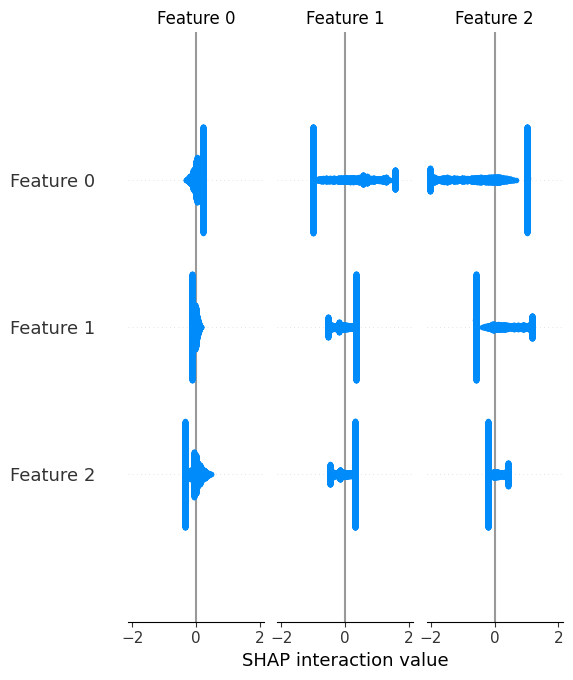

In [247]:
shap.summary_plot(shap_values)

In [248]:
explainer.expected_value

array([-1.37400549, -0.05853405,  1.43253955])

In [250]:
df_X_test.drop(columns=["clases"]).columns

Index(['E6', 'L10', 'L13', 'E8', 'E5', 'L16', 'E2', 'E7', 'L11', 'L14', 'E4',
       'E1', 'E3', 'L17', 'L15', 'L9', 'L12'],
      dtype='str')

# Ablation study

In [ ]:
# E1	C_G1_G3
# E2	C_G1_G4
# E8	rte

# E3	I_G2
# E4	H-H_G1_G2
# E5	IMF
# E6	h_h_g1
# E7	T_H_G3

# L9	IM_l
# L10	xIMF_G2_G4
# L11	xI_G3_G4
# L12	xTH_G2_G4

# L13	Jaro-Winkler_rit1
# L14	Jaro-Winkler_rte_expert1
# L15	Jaro-Winkler_dsf1
# L16	Jaro-Winkler_rit2
# L17	Jaro-Winkler_rit21


In [260]:
#Entities_NoTI = ['C_G1_G4','C_G1_G3','rte']
#Entities_TI= ['I_G2','H-H_G1_G2','IMF','h_h_g1','T_H_G3']
#Lexical_TI = ['IM_l','xIMF_G2_G4','xTH_G2_G4','xI_G3_G4']
#Lexical_NoTI = ['Jaro-Winkler_rit1','Jaro-Winkler_rte_expert1', 'Jaro-Winkler_dsf1','Jaro-Winkler_rit2','Jaro-Winkler_rit21']

Entities_NoTI = ['E1','E2','E8']
Entities_TI= ['E3','E4','E5','E6','E7']
Lexical_TI = ['L9','L10','L11','L12']
Lexical_NoTI = ['L13','L14','L15','L16','L17']



In [261]:
df_X_test['clases'].unique()

array(['NEUTRAL', 'ENTAILMENT', 'CONTRADICTION'], dtype=object)

In [262]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# 1. DEFINIR LOS GRUPOS DISJUNTOS (según lo acordado)
grupos = {
    'lex_puro': Lexical_NoTI,
    'ti_lexica': Lexical_TI,
    'entidades': Entities_NoTI,
    'ti_entidades': Entities_TI
}

# 2. DEFINIR CONFIGURACIONES DE ABLACIÓN
configuraciones = {
    'Todas_17': ['lex_puro', 'ti_lexica', 'entidades', 'ti_entidades'],
    'Solo_Analisis_Semantico': ['entidades','lex_puro'],
    'Solo_Teoria_Info_Total': ['ti_lexica', 'ti_entidades'],
    'Solo_Nivel_Lexico': ['lex_puro', 'ti_lexica'],
    'Solo_Nivel_Entidades': ['entidades', 'ti_entidades'],
    'Sin_lex_puro' : ['ti_lexica','entidades','ti_entidades'],
    'Sin_ti_lexica' : ['lex_puro','entidades','ti_entidades'],
    'Sin_entidades' : ['lex_puro','ti_lexica','ti_entidades'],
    'Sin_ti_entidades' : ['lex_puro','ti_lexica','entidades'],
    'lex_puro': ['lex_puro'],
    'ti_lexica': ['ti_lexica'],
    'entidades': ['entidades'],
    'ti_entidades': ['ti_entidades'],
}

# 3. CARGAR TUS DATOS (AJUSTA ESTO)
# X_train, X_test, y_train, y_test = ... tus DataFrames y arrays

def evaluar_configuracion(features_list, X_train, X_test, y_train, y_test, config_name):
    """
    Entrena y evalúa un modelo con un subconjunto de features.
    """
    # Seleccionar features
    X_train_sub = X_train[features_list]
    X_test_sub = X_test[features_list]
    
    # Entrenar modelo (mismos hiperparámetros que tu modelo final)
    model = LogisticRegression(random_state=421, max_iter=1000, C=1.0)
    model.fit(X_train_sub, y_train)
    
    # Predecir y evaluar
    y_pred = model.predict(X_test_sub)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # Obtener métricas por clase si es necesario
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    return {
        'config': config_name,
        'n_features': len(features_list),
        'accuracy': accuracy,
        'f1_macro': f1,
        'f1_entailment': report.get('ENTAILMENT', {}).get('f1-score', 0) if 'ENTAILMENT' in report else 0,
        'f1_contradiction': report.get('CONTRADICTION', {}).get('f1-score', 0) if 'CONTRADICTION' in report else 0,
        'f1_neutral': report.get('NEUTRAL', {}).get('f1-score', 0) if 'NEUTRAL' in report else 0,
        'model': model
    }

def ejecutar_ablacion_completa(X_train, X_test, y_train, y_test):
    """
    Ejecuta todas las configuraciones de ablación.
    """
    resultados = []
    
    # Primero, expandir los grupos a listas de features
    features_por_grupo = {}
    for grupo_nombre, feature_list in grupos.items():
        features_por_grupo[grupo_nombre] = feature_list
    
    # Evaluar cada configuración
    for config_nombre, grupos_incluidos in configuraciones.items():
        # Obtener todas las features de esta configuración
        features_config = []
        for grupo in grupos_incluidos:
            features_config.extend(features_por_grupo[grupo])
        
        # Eliminar duplicados (por si acaso)
        features_config = list(set(features_config))
        
        print(f"Evaluando: {config_nombre} ({len(features_config)} features)...")
        
        resultado = evaluar_configuracion(
            features_config, X_train, X_test, y_train, y_test, config_nombre
        )
        resultados.append(resultado)
    
    # Crear DataFrame con resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Ordenar por accuracy descendente
    df_resultados = df_resultados.sort_values('accuracy', ascending=False)
    
    return df_resultados

# 4. EJECUTAR ANÁLISIS (descomenta cuando tengas tus datos)
# df_ablacion = ejecutar_ablacion_completa(X_train, X_test, y_train, y_test)

# 5. VISUALIZAR RESULTADOS
def visualizar_resultados_ablacion(df_resultados):
    """
    Genera gráficos para los resultados de ablación.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Gráfico 1: Accuracy por configuración
    colors = ['green' if 'Todas' in name else ('orange' if 'Sin' in name else 'blue') 
              for name in df_resultados['config']]
    
    bars1 = axes[0].barh(range(len(df_resultados)), df_resultados['accuracy'], color=colors)
    axes[0].set_yticks(range(len(df_resultados)))
    axes[0].set_yticklabels(df_resultados['config'])
    axes[0].set_xlabel('Accuracy')
    axes[0].set_title('Rendimiento por Configuración de Ablación')
    axes[0].axvline(x=0.83, color='red', linestyle='--', alpha=0.5, label='Modelo Completo (0.83)')
    axes[0].legend()
    
    # Añadir valores en las barras
    for i, (acc, n_feat) in enumerate(zip(df_resultados['accuracy'], df_resultados['n_features'])):
        axes[0].text(acc + 0.005, i, f'{acc:.2f} ({n_feat}f)', va='center', fontsize=9)
    
    # Gráfico 2: Comparación F1 por clase para configuraciones clave
    configs_clave = ['Todas_17', 'Solo_Analisis_Semantico', 'Solo_Teoria_Info_Total', 'Sin_TI']
    df_clave = df_resultados[df_resultados['config'].isin(configs_clave)]
    
    x = np.arange(len(df_clave))
    width = 0.25
    
    axes[1].barh(x - width/2, df_clave['f1_entailment'], width, label='F1 Entailment', color='lightblue')
    axes[1].barh(x + width/2, df_clave['f1_contradiction'], width, label='F1 Contradiction', color='lightcoral')
    axes[1].barh(x + 2*width/2, df_clave['f1_neutral'], width, label='F1 Neutral', color='lightgreen')
    axes[1].set_yticks(x)
    axes[1].set_yticklabels(df_clave['config'])
    axes[1].set_xlabel('F1-Score')
    axes[1].set_title('F1 por Clase (Configuraciones Clave)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('resultados_ablacion.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# 6. GUARDAR RESULTADOS
def guardar_resultados(df_resultados, archivo='resultados_ablacion.csv'):
    """
    Guarda los resultados en CSV y genera tabla LaTeX.
    """
    # Guardar CSV
    df_resultados.to_csv(archivo, index=False)
    
    # Generar código LaTeX para la tabla
    latex_code = df_resultados.to_latex(
        index=False,
        column_format='lccc',
        float_format="{:0.3f}".format,
        caption='Resultados del Análisis de Ablación en SICK-CE',
        label='tab:ablacion'
    )
    
    # Guardar LaTeX
    with open('tabla_ablacion.tex', 'w') as f:
        f.write(latex_code)
    
    print("✅ Resultados guardados en CSV y LaTeX")
    return latex_code



Evaluando: Todas_17 (17 features)...
Evaluando: Solo_Analisis_Semantico (8 features)...
Evaluando: Solo_Teoria_Info_Total (9 features)...
Evaluando: Solo_Nivel_Lexico (9 features)...
Evaluando: Solo_Nivel_Entidades (8 features)...
Evaluando: Sin_lex_puro (12 features)...
Evaluando: Sin_ti_lexica (13 features)...
Evaluando: Sin_entidades (14 features)...
Evaluando: Sin_ti_entidades (12 features)...
Evaluando: lex_puro (5 features)...
Evaluando: ti_lexica (4 features)...
Evaluando: entidades (3 features)...
Evaluando: ti_entidades (5 features)...

RESULTADOS DE ABLACIÓN
                     config  n_features  accuracy  f1_macro
0                  Todas_17          17  0.827523  0.816314
6             Sin_ti_lexica          13  0.819164  0.808982
7             Sin_entidades          14  0.817941  0.803924
8          Sin_ti_entidades          12  0.810805  0.791293
3         Solo_Nivel_Lexico           9  0.808970  0.790889
5              Sin_lex_puro          12  0.805301  0.782300
1   S

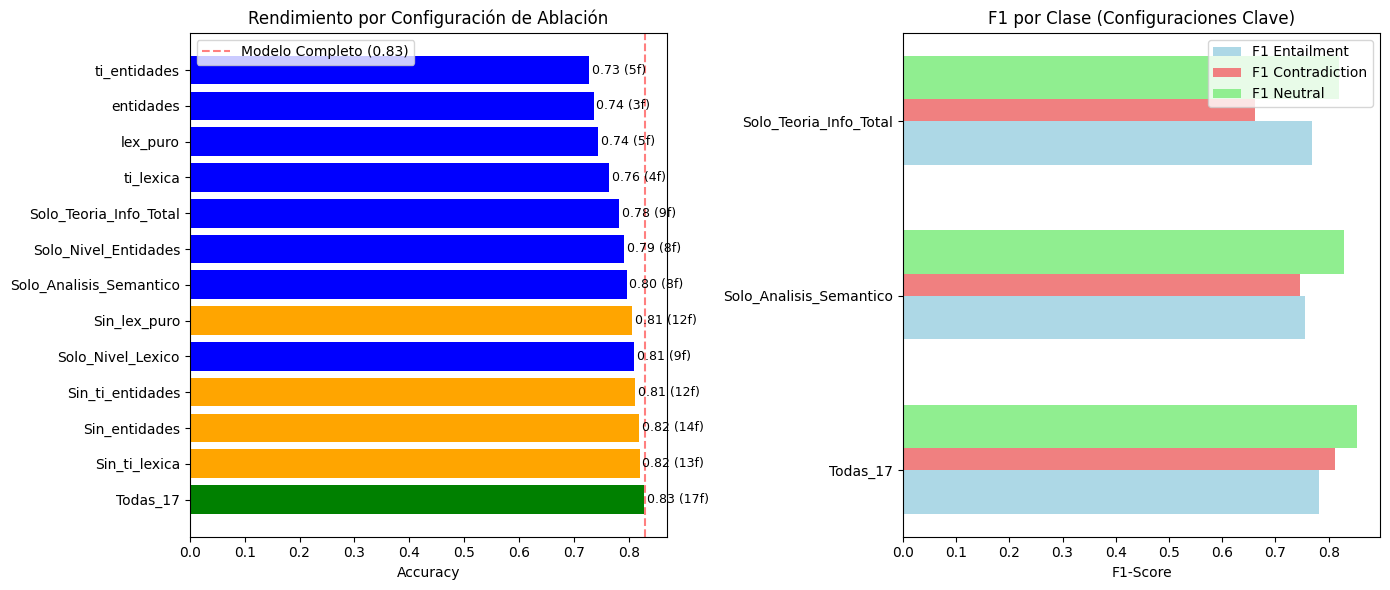

✅ Resultados guardados en CSV y LaTeX


In [263]:
# EJECUCIÓN PRINCIPAL (descomenta cuando todo esté listo)
if __name__ == "__main__":
    # 1. Cargar tus datos
    # X_train, X_test, y_train, y_test = cargar_tus_datos()
    
    # 2. Ejecutar ablación
    df_ablacion = ejecutar_ablacion_completa(df_X_train, df_X_test, df_X_train["clases"], df_X_test["clases"])
    
    # 3. Mostrar resultados
    print("\n" + "="*60)
    print("RESULTADOS DE ABLACIÓN")
    print("="*60)
    print(df_ablacion[['config', 'n_features', 'accuracy', 'f1_macro']])
    
    # 4. Visualizar
    visualizar_resultados_ablacion(df_ablacion)
    
    # 5. Guardar
    guardar_resultados(df_ablacion)

Evaluando: Todas_17 (17 features)...
Evaluando: Solo_Analisis_Semantico (8 features)...
Evaluando: Solo_Teoria_Info_Total (9 features)...
Evaluando: Solo_Nivel_Lexico (9 features)...
Evaluando: Solo_Nivel_Entidades (8 features)...
Evaluando: Sin_lex_puro (12 features)...
Evaluando: Sin_ti_lexica (13 features)...
Evaluando: Sin_entidades (14 features)...
Evaluando: Sin_ti_entidades (12 features)...
Evaluando: lex_puro (5 features)...
Evaluando: ti_lexica (4 features)...
Evaluando: entidades (3 features)...
Evaluando: ti_entidades (5 features)...

RESULTADOS DE ABLACIÓN
                     config  n_features  accuracy  f1_macro
0                  Todas_17          17  0.958412  0.952967
7             Sin_entidades          14  0.957940  0.952415
3         Solo_Nivel_Lexico           9  0.956994  0.951590
6             Sin_ti_lexica          13  0.954631  0.948912
1   Solo_Analisis_Semantico           8  0.954631  0.949163
8          Sin_ti_entidades          12  0.954159  0.948435
9    

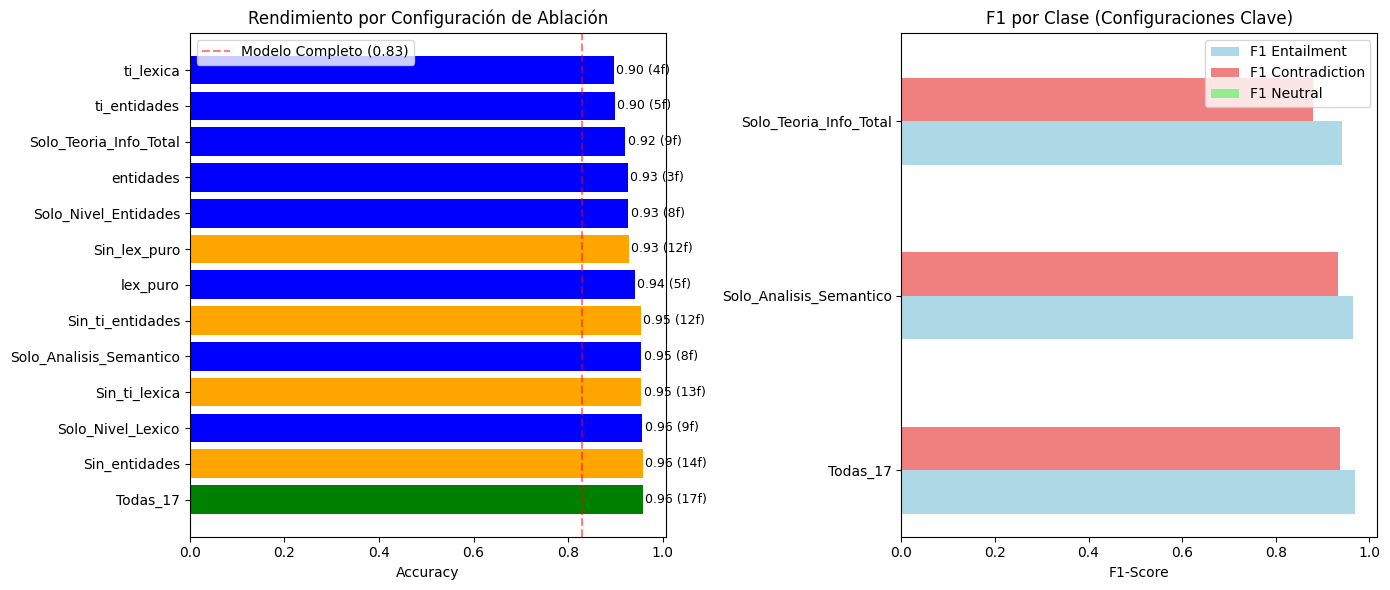

✅ Resultados guardados en CSV y LaTeX


'\\begin{table}\n\\caption{Resultados del Análisis de Ablación en SICK-CE}\n\\label{tab:ablacion}\n\\begin{tabular}{lccc}\n\\toprule\nconfig & n_features & accuracy & f1_macro & f1_entailment & f1_contradiction & f1_neutral & model \\\\\n\\midrule\nTodas_17 & 17 & 0.958 & 0.953 & 0.969 & 0.937 & 0 & LogisticRegression(max_iter=1000, random_state=421) \\\\\nSin_entidades & 14 & 0.958 & 0.952 & 0.969 & 0.936 & 0 & LogisticRegression(max_iter=1000, random_state=421) \\\\\nSolo_Nivel_Lexico & 9 & 0.957 & 0.952 & 0.968 & 0.935 & 0 & LogisticRegression(max_iter=1000, random_state=421) \\\\\nSin_ti_lexica & 13 & 0.955 & 0.949 & 0.966 & 0.932 & 0 & LogisticRegression(max_iter=1000, random_state=421) \\\\\nSolo_Analisis_Semantico & 8 & 0.955 & 0.949 & 0.966 & 0.932 & 0 & LogisticRegression(max_iter=1000, random_state=421) \\\\\nSin_ti_entidades & 12 & 0.954 & 0.948 & 0.966 & 0.931 & 0 & LogisticRegression(max_iter=1000, random_state=421) \\\\\nlex_puro & 5 & 0.941 & 0.934 & 0.956 & 0.911 & 0 & 

In [264]:

df_ablacionCE = ejecutar_ablacion_completa(df_X_train_C_E.drop(columns=['clases']), df_X_test_C_E.drop(columns=['clases']), df_X_train_C_E["clases"], df_X_test_C_E["clases"])

# 3. Mostrar resultados
print("\n" + "="*60)
print("RESULTADOS DE ABLACIÓN")
print("="*60)
print(df_ablacionCE[['config', 'n_features', 'accuracy', 'f1_macro']])

# 4. Visualizar
visualizar_resultados_ablacion(df_ablacionCE)

# 5. Guardar
guardar_resultados(df_ablacionCE)

In [268]:
len(predictions_CEN)

4905

# Revisión de fallas

In [272]:
check["clases"].unique()

array(['NEUTRAL', 'ENTAILMENT', 'CONTRADICTION', 9], dtype=object)

In [ ]:
#check=test.copy()
check["predicciones"]=predictions_CEN
check

ValueError: Length of values (4905) does not match length of index (4906)

In [167]:
check.columns

Index(['Texto', 'Hipotesis', 'TextoL', 'HipotesisL', 'dicEntT', 'dicEntH',
       'ConteosR', 'ConteosG1', 'ConteosG2', 'ConteosG3',
       ...
       'hipH', 'clases', 'rte', 'H-H_G1', 'H-H_G2', 'H-H_G3', 'H-H_G4',
       'H-H_G1_G2', 'H-H_G1_G3', 'H-H_G1_G4'],
      dtype='object', length=309)

In [168]:
check[(check["predicciones"]!=check["clases"]) & (check["clases"]=="NEUTRAL") & (check["predicciones"]=="ENTAILMENT")].index

KeyError: 'predicciones'

In [180]:
indice=4
print(check["Texto"][indice])
print(check["TextoL"][indice])
print(check["dicEntT"][indice])
print(check["Hipotesis"][indice])
print(check["HipotesisL"][indice])
print(check["dicEntH"][indice])
print(check["clases"][indice])
print(check["predicciones"][indice])
print(check["ConteosG1"][indice])
print(check["ConteosG2"][indice])
print(check["ConteosG3"][indice])
print(check["ConteosG4"][indice])
print(check["ranking"][indice])

a brown dog is attacking another animal in front of the man in pants
['a', 'brown', 'dog', 'be', 'attack', 'another', 'animal', 'in', 'front', 'of', 'the', 'man', 'in', 'pant']
{'brown': set(), 'dog': {'brown'}, 'attack': {'be', 'in'}, 'animal': set(), 'front': set(), 'man': set(), 'pant': set()}
a brown dog is helping another animal in front of the man in pants
['a', 'brown', 'dog', 'be', 'help', 'another', 'animal', 'in', 'front', 'of', 'the', 'man', 'in', 'pant']
{'brown': set(), 'dog': {'brown'}, 'help': {'be', 'in'}, 'animal': set(), 'front': set(), 'man': set(), 'pant': set()}
NEUTRAL
ENTAILMENT
[(' brown', 'same', ' brown'), ('brown dog', 'same', 'brown dog'), (' animal', 'same', ' animal'), (' front', 'same', ' front'), (' man', 'same', ' man'), (' pant', 'same', ' pant')]
[]
[]
[('', 'unknown', 'help')]
{'front': np.float64(0.7924812503605779), 'animal': np.float64(0.45914791702724467), 'man': np.float64(0.45914791702724467), 'pant': np.float64(0.45914791702724467), 'dog': np.

# revisión de relaciones

In [181]:
for c_ in check.iterrows():
    print(c_[1]["ConteosG1"])
    print(c_[1]["ConteosG2"])
    print(c_[1]["ConteosG3"])
    print(c_[1]["ConteosG4"])
    break

[('outdoors play', 'same', ' play')]
[('no man', 'distinct_from', ' group'), ('no boy', 'distinct_from', ' kid'), ('no boy', 'antonym', ' old'), ('no man', 'distinct_from', 'old man'), (' be', 'antonym', ' stand')]
[('yard', 'synonym', 'outdoors')]
[('', 'unknown', 'background')]


# SHAP

In [204]:
df_X_train_C_E

,h_h_g1,xIMF_G2_G4,Jaro-Winkler_rit1,rte,IMF,Jaro-Winkler_rit2,C_G1_G4,T_H_G3,xI_G3_G4,Jaro-Winkler_rte_expert1,H-H_G1_G2,C_G1_G3,I_G2,Jaro-Winkler_rit21,Jaro-Winkler_dsf1,IM_l,xTH_G2_G4,clases
2,1.059815,-1.125560,0.168429,0.677510,1.391606,-0.621056,-0.830574,0.391533,-1.048593,0.233279,-0.969647,1.085040,-0.201715,-1.264297,0.303760,0.182943,-0.407867,ENTAILMENT
11,0.517593,-1.125560,0.181744,1.202275,-0.095084,1.571482,0.305250,1.062209,0.848422,0.837422,-1.117512,1.085040,1.009765,0.958844,-1.127906,1.043493,0.061701,ENTAILMENT
14,0.030346,1.948940,-1.054907,-0.921772,0.435876,0.597021,-0.100401,0.217332,-0.282285,-1.269533,1.073574,0.107207,-0.256775,-1.258897,-1.125675,0.446554,-0.337200,CONTRADICTION
15,0.298497,0.165730,1.329573,0.245383,-0.487996,0.597021,1.116554,1.859180,-0.323272,1.071933,-0.842557,0.107207,0.592093,1.076459,1.101465,0.781137,-0.198017,ENTAILMENT
19,-1.635561,-1.125560,1.788190,1.577106,-1.157006,0.945042,1.116554,0.306610,0.219273,1.126772,1.123677,1.085040,0.853723,1.131154,1.153626,0.979156,-2.244621,ENTAILMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325,0.379672,0.073495,-0.142477,0.332056,-0.535782,-1.717324,1.116554,0.705096,-1.547056,0.330734,-0.950095,0.107207,-0.971968,0.337194,0.396456,-0.286342,-0.539952,ENTAILMENT
4326,0.379672,0.073495,-0.007310,0.361459,-0.535782,-1.443257,1.116554,0.413308,-1.429931,0.513822,-1.113846,0.107207,-0.948562,0.519805,0.570605,-0.076943,-0.335427,ENTAILMENT
4327,0.517593,1.603059,-1.053813,-0.921772,-0.095084,1.055591,0.305250,0.426373,-0.505181,-1.268535,1.190888,0.433151,-0.186557,-1.257902,-1.124726,1.074483,0.032321,CONTRADICTION
4330,1.375041,0.934355,-1.063271,0.257209,0.836373,-0.750028,-0.274252,0.234752,-0.898255,-1.279880,-1.118734,0.526278,-0.538766,-1.268298,-1.135518,0.283246,-0.542395,ENTAILMENT


In [207]:
temp=df_X_train_C_E.copy()
df_X_train_C_E

,h_h_g1,xIMF_G2_G4,Jaro-Winkler_rit1,rte,IMF,Jaro-Winkler_rit2,C_G1_G4,T_H_G3,xI_G3_G4,Jaro-Winkler_rte_expert1,H-H_G1_G2,C_G1_G3,I_G2,Jaro-Winkler_rit21,Jaro-Winkler_dsf1,IM_l,xTH_G2_G4,clases
2,1.059815,-1.125560,0.168429,0.677510,1.391606,-0.621056,-0.830574,0.391533,-1.048593,0.233279,-0.969647,1.085040,-0.201715,-1.264297,0.303760,0.182943,-0.407867,ENTAILMENT
11,0.517593,-1.125560,0.181744,1.202275,-0.095084,1.571482,0.305250,1.062209,0.848422,0.837422,-1.117512,1.085040,1.009765,0.958844,-1.127906,1.043493,0.061701,ENTAILMENT
14,0.030346,1.948940,-1.054907,-0.921772,0.435876,0.597021,-0.100401,0.217332,-0.282285,-1.269533,1.073574,0.107207,-0.256775,-1.258897,-1.125675,0.446554,-0.337200,CONTRADICTION
15,0.298497,0.165730,1.329573,0.245383,-0.487996,0.597021,1.116554,1.859180,-0.323272,1.071933,-0.842557,0.107207,0.592093,1.076459,1.101465,0.781137,-0.198017,ENTAILMENT
19,-1.635561,-1.125560,1.788190,1.577106,-1.157006,0.945042,1.116554,0.306610,0.219273,1.126772,1.123677,1.085040,0.853723,1.131154,1.153626,0.979156,-2.244621,ENTAILMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325,0.379672,0.073495,-0.142477,0.332056,-0.535782,-1.717324,1.116554,0.705096,-1.547056,0.330734,-0.950095,0.107207,-0.971968,0.337194,0.396456,-0.286342,-0.539952,ENTAILMENT
4326,0.379672,0.073495,-0.007310,0.361459,-0.535782,-1.443257,1.116554,0.413308,-1.429931,0.513822,-1.113846,0.107207,-0.948562,0.519805,0.570605,-0.076943,-0.335427,ENTAILMENT
4327,0.517593,1.603059,-1.053813,-0.921772,-0.095084,1.055591,0.305250,0.426373,-0.505181,-1.268535,1.190888,0.433151,-0.186557,-1.257902,-1.124726,1.074483,0.032321,CONTRADICTION
4330,1.375041,0.934355,-1.063271,0.257209,0.836373,-0.750028,-0.274252,0.234752,-0.898255,-1.279880,-1.118734,0.526278,-0.538766,-1.268298,-1.135518,0.283246,-0.542395,ENTAILMENT


In [ ]:
# E1	C_G1_G3
# E2	C_G1_G4
# E3	I_G2
# E4	H-H_G1_G2
# E5	IMF
# E6	h_h_g1
# E7	T_H_G3
# E8	rte
# L10	xIMF_G2_G4
# L11	xI_G3_G4
# L12	xTH_G2_G4
# L13	Jaro-Winkler_rit1
# L14	Jaro-Winkler_rte_expert1
# L15	Jaro-Winkler_dsf1
# L16	Jaro-Winkler_rit2
# L17	Jaro-Winkler_rit21
# L9	IM_l


In [174]:
# dir_new_names={'I_G2':'E1', 'C_G1_G3':'E2','C_G1_G4':'E3','h_h_g1':'E4','T_H_G3':'E5' ,
#  'H-H_G1_G2': 'E6' ,'xIMF_G2_G4':'E7', 'rte':'E8','xTH_G2_G4':'L9','xI_G3_G4':'L10',
# 'xIMF_G2_G4':'L11','IMF':'L12', 'Jaro-Winkler_rit1':'L13','Jaro-Winkler_rte_expert1' : 'L14', 
#  'Jaro-Winkler_dsf1':'L15','Jaro-Winkler_rit2':'L16', 'Jaro-Winkler_rit21':'L_17'}
dir_new_names={'I_G2':'E3', 'C_G1_G3':'E1','C_G1_G4':'E2','h_h_g1':'E6','T_H_G3':'E7' ,
 'H-H_G1_G2': 'E4', 'IMF':'E5','IM_l':'L9', 'rte':'E8','xTH_G2_G4':'L12','xI_G3_G4':'L11',
'xIMF_G2_G4':'L10', 'Jaro-Winkler_rit1':'L13','Jaro-Winkler_rte_expert1' : 'L14', 
 'Jaro-Winkler_dsf1':'L15','Jaro-Winkler_rit2':'L16', 'Jaro-Winkler_rit21':'L_17'}
dir_new_names

{'I_G2': 'E3',
 'C_G1_G3': 'E1',
 'C_G1_G4': 'E2',
 'h_h_g1': 'E6',
 'T_H_G3': 'E7',
 'H-H_G1_G2': 'E4',
 'IMF': 'E5',
 'IM_l': 'L9',
 'rte': 'E8',
 'xTH_G2_G4': 'L12',
 'xI_G3_G4': 'L11',
 'xIMF_G2_G4': 'L10',
 'Jaro-Winkler_rit1': 'L13',
 'Jaro-Winkler_rte_expert1': 'L14',
 'Jaro-Winkler_dsf1': 'L15',
 'Jaro-Winkler_rit2': 'L16',
 'Jaro-Winkler_rit21': 'L_17'}

In [ ]:
df_X_train_C_E.rename(columns=dir_new_names, inplace=True)
df_X_train_C_E

,E4,L11,L13,E8,L12,L16,E3,E5,L10,L14,E6,E2,E1,L_17,L15,L12,L9,clases
2,1.059815,-1.125560,0.168429,0.677510,1.391606,-0.621056,-0.830574,0.391533,-1.048593,0.233279,-0.969647,1.085040,-0.201715,-1.264297,0.303760,0.182943,-0.407867,ENTAILMENT
11,0.517593,-1.125560,0.181744,1.202275,-0.095084,1.571482,0.305250,1.062209,0.848422,0.837422,-1.117512,1.085040,1.009765,0.958844,-1.127906,1.043493,0.061701,ENTAILMENT
14,0.030346,1.948940,-1.054907,-0.921772,0.435876,0.597021,-0.100401,0.217332,-0.282285,-1.269533,1.073574,0.107207,-0.256775,-1.258897,-1.125675,0.446554,-0.337200,CONTRADICTION
15,0.298497,0.165730,1.329573,0.245383,-0.487996,0.597021,1.116554,1.859180,-0.323272,1.071933,-0.842557,0.107207,0.592093,1.076459,1.101465,0.781137,-0.198017,ENTAILMENT
19,-1.635561,-1.125560,1.788190,1.577106,-1.157006,0.945042,1.116554,0.306610,0.219273,1.126772,1.123677,1.085040,0.853723,1.131154,1.153626,0.979156,-2.244621,ENTAILMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325,0.379672,0.073495,-0.142477,0.332056,-0.535782,-1.717324,1.116554,0.705096,-1.547056,0.330734,-0.950095,0.107207,-0.971968,0.337194,0.396456,-0.286342,-0.539952,ENTAILMENT
4326,0.379672,0.073495,-0.007310,0.361459,-0.535782,-1.443257,1.116554,0.413308,-1.429931,0.513822,-1.113846,0.107207,-0.948562,0.519805,0.570605,-0.076943,-0.335427,ENTAILMENT
4327,0.517593,1.603059,-1.053813,-0.921772,-0.095084,1.055591,0.305250,0.426373,-0.505181,-1.268535,1.190888,0.433151,-0.186557,-1.257902,-1.124726,1.074483,0.032321,CONTRADICTION
4330,1.375041,0.934355,-1.063271,0.257209,0.836373,-0.750028,-0.274252,0.234752,-0.898255,-1.279880,-1.118734,0.526278,-0.538766,-1.268298,-1.135518,0.283246,-0.542395,ENTAILMENT


In [241]:
df_X_test_C_E.rename(columns=dir_new_names, inplace=True)
df_X_test_C_E

,E4,L11,L13,E8,L12,L16,E3,E5,L10,L14,E6,E2,E1,L_17,L15,L12,L9,clases
3,-1.606259,-1.096853,1.698501,1.547851,-1.156331,1.319803,1.125811,0.009175,-0.679249,1.311906,0.949575,1.070362,-0.510084,1.328600,1.322354,1.254971,-0.468776,ENTAILMENT
5,-0.305766,0.567312,-1.078108,-0.933850,0.603829,0.124106,-0.499083,0.984237,-0.920729,-1.297367,1.491964,-0.222401,1.433803,-1.286990,-1.167297,-0.147781,1.309392,CONTRADICTION
9,-1.606259,-1.096853,1.762007,1.547851,-1.156331,1.618727,1.125811,0.099013,-0.046373,1.371663,0.999548,1.070362,-0.439317,1.388503,1.379372,0.992911,-2.249331,ENTAILMENT
10,0.241248,1.229896,-1.071187,-0.933850,-0.615559,0.583989,0.313364,0.099013,-0.603323,-1.295108,0.999548,0.423981,-0.287610,-1.285063,-1.165142,0.992911,-0.279182,CONTRADICTION
12,-1.606259,-1.096853,0.304504,1.547851,-1.156331,0.721954,1.125811,1.337012,0.636812,0.980749,1.688199,1.070362,0.619538,1.108959,1.006379,0.912688,1.300295,ENTAILMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4772,0.630053,0.105044,0.017303,0.311359,-0.536033,-1.463930,1.125811,0.714725,-1.402178,0.499309,-0.949393,0.100790,-0.978549,0.514036,0.547011,-0.285306,-0.471773,ENTAILMENT
4774,0.378892,0.105044,0.017303,0.311359,-0.536033,-1.463930,1.125811,0.714725,-1.396895,0.499309,-0.949393,0.100790,-0.986289,0.514036,0.547011,-0.285306,-0.471773,ENTAILMENT
4775,-1.606259,-1.096853,1.702470,1.547851,-1.156331,1.058244,1.125811,0.171321,-0.673212,1.199860,1.039770,1.070362,-0.536622,1.216284,1.215445,1.130894,-0.389866,ENTAILMENT
4777,-1.606259,-1.096853,1.649937,1.547851,-1.156331,1.354971,1.125811,0.434258,-0.355467,1.266209,1.186032,1.070362,-0.222592,1.282793,1.278752,1.088863,-1.804267,ENTAILMENT


In [242]:
df_X_train_C_E

,E4,L11,L13,E8,L12,L16,E3,E5,L10,L14,E6,E2,E1,L_17,L15,L12,L9,clases
2,1.059815,-1.125560,0.168429,0.677510,1.391606,-0.621056,-0.830574,0.391533,-1.048593,0.233279,-0.969647,1.085040,-0.201715,-1.264297,0.303760,0.182943,-0.407867,ENTAILMENT
11,0.517593,-1.125560,0.181744,1.202275,-0.095084,1.571482,0.305250,1.062209,0.848422,0.837422,-1.117512,1.085040,1.009765,0.958844,-1.127906,1.043493,0.061701,ENTAILMENT
14,0.030346,1.948940,-1.054907,-0.921772,0.435876,0.597021,-0.100401,0.217332,-0.282285,-1.269533,1.073574,0.107207,-0.256775,-1.258897,-1.125675,0.446554,-0.337200,CONTRADICTION
15,0.298497,0.165730,1.329573,0.245383,-0.487996,0.597021,1.116554,1.859180,-0.323272,1.071933,-0.842557,0.107207,0.592093,1.076459,1.101465,0.781137,-0.198017,ENTAILMENT
19,-1.635561,-1.125560,1.788190,1.577106,-1.157006,0.945042,1.116554,0.306610,0.219273,1.126772,1.123677,1.085040,0.853723,1.131154,1.153626,0.979156,-2.244621,ENTAILMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325,0.379672,0.073495,-0.142477,0.332056,-0.535782,-1.717324,1.116554,0.705096,-1.547056,0.330734,-0.950095,0.107207,-0.971968,0.337194,0.396456,-0.286342,-0.539952,ENTAILMENT
4326,0.379672,0.073495,-0.007310,0.361459,-0.535782,-1.443257,1.116554,0.413308,-1.429931,0.513822,-1.113846,0.107207,-0.948562,0.519805,0.570605,-0.076943,-0.335427,ENTAILMENT
4327,0.517593,1.603059,-1.053813,-0.921772,-0.095084,1.055591,0.305250,0.426373,-0.505181,-1.268535,1.190888,0.433151,-0.186557,-1.257902,-1.124726,1.074483,0.032321,CONTRADICTION
4330,1.375041,0.934355,-1.063271,0.257209,0.836373,-0.750028,-0.274252,0.234752,-0.898255,-1.279880,-1.118734,0.526278,-0.538766,-1.268298,-1.135518,0.283246,-0.542395,ENTAILMENT


In [243]:
m_C_E = LogisticRegression(penalty="l2", C=1,max_iter=10000)
#df_X_train_C_E = df_X_train[df_X_train['clases'] != 'NEUTRAL']
m_C_E.fit(df_X_train_C_E.drop(columns=["clases"]), df_X_train_C_E['clases'] )
#df_X_test_C_E = df_X_test[df_X_test['clases'] != 'NEUTRAL']
pred_CE = m_C_E.predict(df_X_test_C_E.drop(columns=["clases"]))
print( classification_report(df_X_test_C_E['clases'], pred_CE) ) 
print( confusion_matrix(df_X_test_C_E['clases'], pred_CE) )

               precision    recall  f1-score   support

CONTRADICTION       0.95      0.92      0.94       712
   ENTAILMENT       0.96      0.98      0.97      1404

     accuracy                           0.96      2116
    macro avg       0.96      0.95      0.95      2116
 weighted avg       0.96      0.96      0.96      2116

[[ 656   56]
 [  31 1373]]


In [244]:
df_X_train_C_E

,E4,L11,L13,E8,L12,L16,E3,E5,L10,L14,E6,E2,E1,L_17,L15,L12,L9,clases
2,1.059815,-1.125560,0.168429,0.677510,1.391606,-0.621056,-0.830574,0.391533,-1.048593,0.233279,-0.969647,1.085040,-0.201715,-1.264297,0.303760,0.182943,-0.407867,ENTAILMENT
11,0.517593,-1.125560,0.181744,1.202275,-0.095084,1.571482,0.305250,1.062209,0.848422,0.837422,-1.117512,1.085040,1.009765,0.958844,-1.127906,1.043493,0.061701,ENTAILMENT
14,0.030346,1.948940,-1.054907,-0.921772,0.435876,0.597021,-0.100401,0.217332,-0.282285,-1.269533,1.073574,0.107207,-0.256775,-1.258897,-1.125675,0.446554,-0.337200,CONTRADICTION
15,0.298497,0.165730,1.329573,0.245383,-0.487996,0.597021,1.116554,1.859180,-0.323272,1.071933,-0.842557,0.107207,0.592093,1.076459,1.101465,0.781137,-0.198017,ENTAILMENT
19,-1.635561,-1.125560,1.788190,1.577106,-1.157006,0.945042,1.116554,0.306610,0.219273,1.126772,1.123677,1.085040,0.853723,1.131154,1.153626,0.979156,-2.244621,ENTAILMENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325,0.379672,0.073495,-0.142477,0.332056,-0.535782,-1.717324,1.116554,0.705096,-1.547056,0.330734,-0.950095,0.107207,-0.971968,0.337194,0.396456,-0.286342,-0.539952,ENTAILMENT
4326,0.379672,0.073495,-0.007310,0.361459,-0.535782,-1.443257,1.116554,0.413308,-1.429931,0.513822,-1.113846,0.107207,-0.948562,0.519805,0.570605,-0.076943,-0.335427,ENTAILMENT
4327,0.517593,1.603059,-1.053813,-0.921772,-0.095084,1.055591,0.305250,0.426373,-0.505181,-1.268535,1.190888,0.433151,-0.186557,-1.257902,-1.124726,1.074483,0.032321,CONTRADICTION
4330,1.375041,0.934355,-1.063271,0.257209,0.836373,-0.750028,-0.274252,0.234752,-0.898255,-1.279880,-1.118734,0.526278,-0.538766,-1.268298,-1.135518,0.283246,-0.542395,ENTAILMENT


SHAP values shape: (2116, 17)
Expected value (base): 1.1335592030210102
🚀 INICIANDO ANÁLISIS SHAP
📊 Creando explainer SHAP...
📈 Calculando SHAP values para conjunto de prueba...
   ✓ SHAP values calculados: shape (2116, 17)
   ✓ Valor base (expected_value): 1.1336

🔍 Buscando ejemplos interesantes...
   ✅ 1261 ejemplos con alta confianza y correctos
   ❌ 26 ejemplos con alta confianza pero incorrectos
   🤔 41 ejemplos con predicción incierta
   ⚡ 2116 ejemplos con gran contribución individual

💡 RECOMENDACIONES PARA ANÁLISIS:
   1. Ejemplo #52: Correcto con alta confianza (prob=0.999)
   2. Ejemplo #1435: Incorrecto con alta confianza (prob=0.995) - ¡Interesante para analizar errores!
   3. Ejemplo #250: Gran influencia de una feature (SHAP=-2.388)

🔎 Analizando ejemplo de ERROR (#1716)...
ANÁLISIS SHAP PARA EJEMPLO #1716
📊 Etiqueta verdadera: CONTRADICTION
🤖 Predicción del modelo: ENTAILMENT
📈 Probabilidades: CONTRADICTION=0.001, ENTAILMENT=0.999

📋 TOP 5 CARACTERÍSTICAS MÁS INFLUYENT

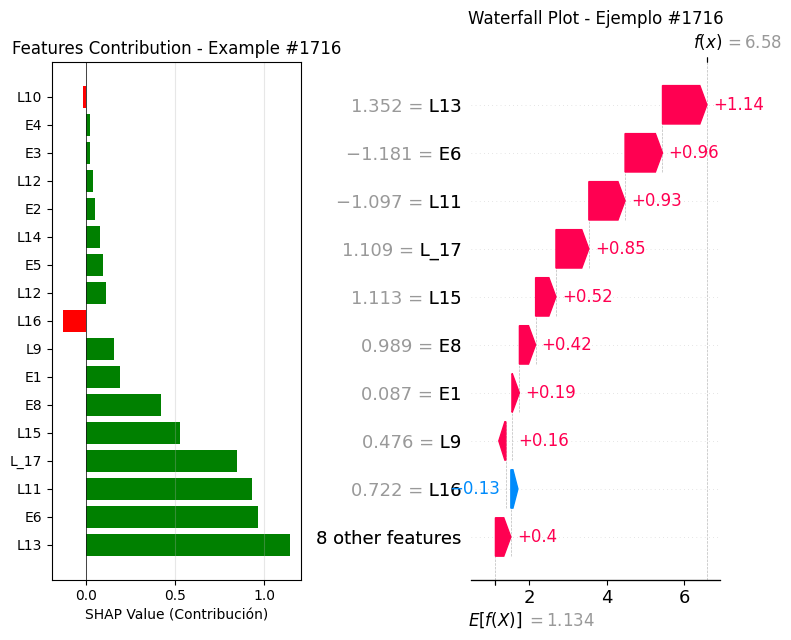


💾 Guardando resultados SHAP...
✅ Análisis SHAP completado y guardado
   - shap_values_array.npy: Valores SHAP completos
   - shap_metadata.json: Metadatos del análisis
⚠️  Por favor, ajusta el script con tus datos antes de ejecutar.


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

explainer = shap.LinearExplainer(m_C_E, df_X_train_C_E.drop(columns=["clases"]), feature_names=df_X_train_C_E.drop(columns=["clases"]).columns.tolist())

# Calcular SHAP values para TODO el conjunto de test
shap_values = explainer.shap_values(df_X_test_C_E.drop(columns=["clases"]))

# Para modelo binario, shap_values es un array 2D (n_samples, n_features)
# expected_value es un escalar (valor base para la clase positiva)
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Expected value (base): {explainer.expected_value}")

# 3. FUNCIÓN PARA ANALIZAR UN EJEMPLO ESPECÍFICO - CORREGIDA
# --------------------------------------------------------------------
def analyze_example_with_shap(example_idx, X_test, y_test, shap_values, model, explainer):
    """
    Analiza un ejemplo específico usando SHAP values.
    
    Args:
        example_idx: Índice del ejemplo en X_test/y_test
        X_test: DataFrame con features de test
        y_test: Array con etiquetas verdaderas
        shap_values: SHAP values calculados previamente
        model: Modelo entrenado
        explainer: Explainer de SHAP
    """
    
    # Verificar que el índice sea válido
    if example_idx >= len(X_test):
        print(f"❌ Error: Índice {example_idx} fuera de rango. Máximo: {len(X_test)-1}")
        return
    
    # Obtener el ejemplo
    example_features = X_test.iloc[example_idx]
    true_label = y_test.iloc[example_idx] if hasattr(y_test, 'iloc') else y_test[example_idx]
    
    # Obtener predicción del modelo
    pred_proba = model.predict_proba(example_features.values.reshape(1, -1))[0]
    predicted_label = model.predict(example_features.values.reshape(1, -1))[0]
    
    # Obtener SHAP values para este ejemplo
    example_shap_values = shap_values[example_idx]
    
    # Mapeo de etiquetas
    label_map = {0: "CONTRADICTION", 1: "ENTAILMENT"}
    
    print("=" * 70)
    print(f"ANÁLISIS SHAP PARA EJEMPLO #{example_idx}")
    print("=" * 70)
    print(f"📊 Etiqueta verdadera: {label_map.get(true_label, true_label)}")
    print(f"🤖 Predicción del modelo: {label_map.get(predicted_label, predicted_label)}")
    print(f"📈 Probabilidades: CONTRADICTION={pred_proba[0]:.3f}, ENTAILMENT={pred_proba[1]:.3f}")
    print()
    
    # SHAP values: Valores positivos favorecen ENTAILMENT, negativos CONTRADICTION
    # El valor base (expected_value) es el log-odds base antes de considerar features
    
    # Crear DataFrame con las contribuciones
    contrib_df = pd.DataFrame({
        'Feature': X_test.columns.tolist(),
        'Feature_Value': example_features.values,
        'SHAP_Value': example_shap_values,
        'Abs_SHAP': np.abs(example_shap_values)
    })
    
    # Ordenar por valor absoluto de SHAP (contribución más importante primero)
    contrib_df = contrib_df.sort_values('Abs_SHAP', ascending=False)
    
    print("📋 TOP 5 CARACTERÍSTICAS MÁS INFLUYENTES:")
    print("-" * 70)
    for _, row in contrib_df.head(5).iterrows():
        direction = "↑ FAVORECE ENTAILMENT" if row['SHAP_Value'] > 0 else "↓ FAVORECE CONTRADICTION"
        print(f"{row['Feature']:20} SHAP: {row['SHAP_Value']:7.4f} {direction}")
        print(f"                      Valor: {row['Feature_Value']:.4f}")
    print()
    
    # Calcular contribución total (suma de SHAP values)
    total_shap = np.sum(example_shap_values)
    log_odds = explainer.expected_value + total_shap
    probability = 1 / (1 + np.exp(-log_odds))
    
    print(f"📐 Valor base (log-odds): {explainer.expected_value:.4f}")
    print(f"📐 Suma de SHAP values: {total_shap:.4f}")
    print(f"📐 Log-odds final: {log_odds:.4f}")
    print(f"📐 Probabilidad calculada: {probability:.4f} (vs modelo: {pred_proba[1]:.4f})")
    print()
    
    # 4. VISUALIZACIÓN GRÁFICA - VERSIÓN CORREGIDA
    # --------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Gráfico 1: Bar plot de SHAP values
    colors = ['green' if x > 0 else 'red' for x in contrib_df['SHAP_Value']]
    axes[0].barh(range(len(contrib_df)), contrib_df['SHAP_Value'], color=colors)
    axes[0].set_yticks(range(len(contrib_df)))
    axes[0].set_yticklabels(contrib_df['Feature'])
    axes[0].set_xlabel('SHAP Value (Contribución)')
    axes[0].set_title(f'Features Contribution - Example #{example_idx}')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Gráfico 2: Waterfall plot simplificado
    # Crear un objeto Explanation correctamente
    shap_obj = shap.Explanation(
        values=example_shap_values,
        base_values=explainer.expected_value,  # Ahora es un escalar
        data=example_features.values,
        feature_names=X_test.columns.tolist()
    )
    
    shap.waterfall_plot(shap_obj, max_display=10, show=False)
    axes[1].set_title(f'Waterfall Plot - Ejemplo #{example_idx}')
    
    plt.tight_layout()
    plt.show()
    
    return contrib_df, pred_proba, predicted_label, true_label

# 5. FUNCIÓN PARA BUSCAR EJEMPLOS INTERESANTES - MEJORADA
# --------------------------------------------------------------------
def find_interesting_examples(X_test, y_test, model, shap_values, explainer, n_examples=5):
    """
    Encuentra ejemplos interesantes para análisis.
    """
    # Obtener predicciones y probabilidades
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    results = {
        'high_confidence_correct': [],
        'high_confidence_wrong': [], 
        'uncertain': [],
        'large_shap_discrepancy': []
    }
    
    for idx in range(len(X_test)):
        true_label = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
        pred_label = y_pred[idx]
        prob_entailment = y_pred_proba[idx][1]
        
        # Calcular discrepancia SHAP: features que más favorecen vs. etiqueta real
        example_shap = shap_values[idx]
        max_shap_feature_idx = np.argmax(np.abs(example_shap))
        max_shap_value = example_shap[max_shap_feature_idx]
        
        if true_label == pred_label and prob_entailment > 0.85:
            results['high_confidence_correct'].append((idx, prob_entailment, max_shap_value))
        elif true_label != pred_label and prob_entailment > 0.85:
            results['high_confidence_wrong'].append((idx, prob_entailment, max_shap_value))
        elif 0.4 < prob_entailment < 0.6:
            results['uncertain'].append((idx, prob_entailment, max_shap_value))
        
        # Ejemplos con gran contribución de una sola feature
        if np.max(np.abs(example_shap)) > 0.5:  # SHAP value absoluto > 0.5
            results['large_shap_discrepancy'].append((idx, prob_entailment, max_shap_value))
    
    # Ordenar resultados
    for key in results:
        if key == 'high_confidence_correct':
            results[key].sort(key=lambda x: x[1], reverse=True)  # Por probabilidad descendente
        elif key == 'high_confidence_wrong':
            results[key].sort(key=lambda x: x[1], reverse=True)
        elif key == 'large_shap_discrepancy':
            results[key].sort(key=lambda x: abs(x[2]), reverse=True)  # Por SHAP absoluto
    
    return results

# 6. FUNCIÓN PRINCIPAL DE EJECUCIÓN
# --------------------------------------------------------------------
def main_shap_analysis(X_train, X_test, y_train, y_test, model):
    """
    Función principal para ejecutar todo el análisis SHAP.
    """
    print("🚀 INICIANDO ANÁLISIS SHAP")
    print("=" * 60)
    
    # 1. Crear explainer
    print("📊 Creando explainer SHAP...")
    explainer = shap.LinearExplainer(model, X_train, feature_names=X_train.columns.tolist())
    
    # 2. Calcular SHAP values
    print("📈 Calculando SHAP values para conjunto de prueba...")
    shap_values = explainer.shap_values(X_test)
    print(f"   ✓ SHAP values calculados: shape {np.array(shap_values).shape}")
    print(f"   ✓ Valor base (expected_value): {explainer.expected_value:.4f}")
    
    # 3. Encontrar ejemplos interesantes
    print("\n🔍 Buscando ejemplos interesantes...")
    interesting = find_interesting_examples(X_test, y_test, model, shap_values, explainer)
    
    print(f"   ✅ {len(interesting['high_confidence_correct'])} ejemplos con alta confianza y correctos")
    print(f"   ❌ {len(interesting['high_confidence_wrong'])} ejemplos con alta confianza pero incorrectos")
    print(f"   🤔 {len(interesting['uncertain'])} ejemplos con predicción incierta")
    print(f"   ⚡ {len(interesting['large_shap_discrepancy'])} ejemplos con gran contribución individual")
    
    # 4. Mostrar recomendaciones
    print("\n💡 RECOMENDACIONES PARA ANÁLISIS:")
    if interesting['high_confidence_correct']:
        idx, prob, shap_val = interesting['high_confidence_correct'][1]
        print(f"   1. Ejemplo #{idx}: Correcto con alta confianza (prob={prob:.3f})")
    
    if interesting['high_confidence_wrong']:
        idx, prob, shap_val = interesting['high_confidence_wrong'][1]
        print(f"   2. Ejemplo #{idx}: Incorrecto con alta confianza (prob={prob:.3f}) - ¡Interesante para analizar errores!")
    
    if interesting['large_shap_discrepancy']:
        idx, prob, shap_val = interesting['large_shap_discrepancy'][1]
        print(f"   3. Ejemplo #{idx}: Gran influencia de una feature (SHAP={shap_val:.3f})")
    
    # 5. Analizar un ejemplo por defecto (o pedir al usuario)
    print("\n" + "=" * 60)
    
    # Si hay ejemplos de error, analizar uno (son más interesantes)
    if interesting['high_confidence_wrong']:
        example_idx = interesting['high_confidence_wrong'][0][0]
        print(f"🔎 Analizando ejemplo de ERROR (#{example_idx})...")
    elif interesting['high_confidence_correct']:
        example_idx = interesting['high_confidence_correct'][0][0]
        print(f"🔎 Analizando ejemplo CORRECTO (#{example_idx})...")
    else:
        example_idx = 0
        print(f"🔎 Analizando primer ejemplo (#{example_idx})...")
    
    # Ejecutar análisis detallado
    results = analyze_example_with_shap(
        example_idx, X_test, y_test, shap_values, model, explainer
    )
    
    # 6. Guardar resultados para uso posterior
    print("\n💾 Guardando resultados SHAP...")
    np.save('shap_values_array.npy', shap_values)
    
    # Guardar metadata
    metadata = {
        'feature_names': X_test.columns.tolist(),
        'expected_value': explainer.expected_value,
        'example_analyzed': example_idx
    }
    
    import json
    with open('shap_metadata.json', 'w') as f:
        json.dump(metadata, f)
    
    print("✅ Análisis SHAP completado y guardado")
    print("   - shap_values_array.npy: Valores SHAP completos")
    print("   - shap_metadata.json: Metadatos del análisis")
    
    return explainer, shap_values, results

# # 7. EJECUCIÓN (descomenta y ajusta con tus datos)
# # --------------------------------------------------------------------
if __name__ == "__main__":
    
    # REEMPLAZA ESTO CON TUS DATOS REALES
    # X_train, X_test, y_train, y_test = carga_tus_datos()
    # model = tu_modelo_entrenado
    model = m_C_E
    # Ejecutar análisis completo
    explainer, shap_values, results = main_shap_analysis(
        df_X_train_C_E.drop(columns=["clases"]), df_X_test_C_E.drop(columns=["clases"]), df_X_train_C_E["clases"], df_X_test_C_E["clases"], model
    )
    
    # Para analizar un ejemplo específico manualmente:
    # analyze_example_with_shap(42, X_test, y_test, shap_values, model, explainer)
    
    #model = m_C_E

    print("⚠️  Por favor, ajusta el script con tus datos antes de ejecutar.")

In [246]:
test_original = pd.read_pickle('output/relationships/MONALOG/TEST_1.csv.pickle')
test_original = test_original[test_original["clases"]!="NEUTRAL"]
test_original['predicciones']=pred_CE
test_original = test_original.reset_index(drop=True)
test_original

,Texto,Hipotesis,TextoL,HipotesisL,dicEntT,dicEntH,ConteosR,ConteosG1,ConteosG2,ConteosG3,...,sinT,sinH,antT,antH,HipT,HipH,hipT,hipH,clases,predicciones
0,a brown dog is attacking another animal in fro...,a brown dog is attacking another animal in fro...,"[a, brown, dog, be, attack, another, animal, i...","[a, brown, dog, be, attack, another, animal, i...","{'brown': {}, 'dog': {'brown'}, 'attack': {'be...","{'brown': {}, 'dog': {'brown'}, 'attack': {'be...","[( brown, same, brown), (brown dog, same, bro...","[( brown, same, brown), (brown dog, same, bro...",[],[],...,"[{ess, ette, an, she, ampere, arc, angstrom, p...","[{ess, ette, an, she, ampere, arc, angstrom, p...","[{}, {}, {computer, cut, cat_maybe, again, bit...","[{}, {}, {computer, cut, cat_maybe, again, bit...","[{send_criminal_to_prison, set_containing_one_...","[{send_criminal_to_prison, set_containing_one_...","[{cilia, ha, apiece, ahold, phenomena, jack_la...","[{cilia, ha, apiece, ahold, phenomena, jack_la...",ENTAILMENT,ENTAILMENT
1,two dogs are wrestling and hugging,there is no dog wrestling and hugging,"[two, dog, be, wrestle, and, hug]","[there, be, no, dog, wrestling, and, hug]","{'dog': {'two'}, 'wrestle': {'be'}, 'hug': {}}","{'dog': {}, 'wrestling': {'no'}, 'hug': {}}","[(two dog, same, dog), ( hug, same, hug), ( ...","[(two dog, same, dog), ( hug, same, hug)]","[( wrestle, distinct_from, no wrestling)]",[],...,"[{2, ii, deuce}, {chase, doggy, newkie_brown, ...","[{thither}, {exist, bean’t, embody, cost, hung...","[{one}, {computer, cut, cat_maybe, again, bitc...","[{}, {exist, then, existing, was, wasp, to, or...","[{2, digit, number, deuce, greater_than_one, c...","[{their, location, thither, they’re}, {exist, ...","[{two_stroke, 2, twotino, craps, twosies, twof...","[{dar, thereover, thereby, therearound, theref...",CONTRADICTION,CONTRADICTION
2,a person in a black jacket is doing tricks on ...,a man in a black jacket is doing tricks on a m...,"[a, person, in, a, black, jacket, be, do, tric...","[a, man, in, a, black, jacket, be, do, trick, ...","{'person': {'in'}, 'black': {}, 'jacket': {'bl...","{'man': {'in'}, 'black': {}, 'jacket': {'black...","[( person, synonym, man), ( black, same, bla...","[( person, synonym, man), ( black, same, bla...",[],[],...,"[{ess, ette, an, she, ampere, arc, angstrom, p...","[{ess, ette, an, she, ampere, arc, angstrom, p...","[{}, {people, thing, animal, group, put_togeth...","[{}, {people, her, adult, wifes_husband, wifes...","[{send_criminal_to_prison, set_containing_one_...","[{send_criminal_to_prison, set_containing_one_...","[{cilia, ha, apiece, ahold, phenomena, jack_la...","[{cilia, ha, apiece, ahold, phenomena, jack_la...",ENTAILMENT,ENTAILMENT
3,there is no man in a black jacket doing tricks...,a person in a black jacket is doing tricks on ...,"[there, be, no, man, in, a, black, jacket, do,...","[a, person, in, a, black, jacket, be, do, tric...","{'man': {'no', 'in'}, 'black': {}, 'jacket': {...","{'person': {'in'}, 'black': {}, 'jacket': {'bl...","[( black, same, black), (black jacket, same, ...","[( black, same, black), (black jacket, same, ...","[(no man, distinct_from, person)]",[],...,"[{thither}, {exist, bean’t, embody, cost, hung...","[{ess, ette, an, she, ampere, arc, angstrom, p...","[{}, {exist, then, existing, was, wasp, to, or...","[{}, {people, thing, animal, group, put_togeth...","[{their, location, thither, they’re}, {exist, ...","[{send_criminal_to_prison, set_containing_one_...","[{dar, thereover, thereby, therearound, theref...","[{cilia, ha, apiece, ahold, phenomena, jack_la...",CONTRADICTION,CONTRADICTION
4,a skilled person is riding a bicycle on one wheel,a person is riding the bicycle on one wheel,"[a, skilled, person, be, ride, a, bicycle, on,...","[a, person, be, ride, the, bicycle, on, one, w...","{'skilled': {}, 'person': {'skilled'}, 'ride':...","{'person': {}, 'ride': {'on', 'be'}, 'bicycle'...","[(skilled person, same, person), (on ride, sa...","[(skilled person, same, person), (

In [247]:
def datos(df,ind):
    print(df.at[ind,"Texto"])
    print(df.at[ind,"Hipotesis"])
    print(df.at[ind,"ConteosG1"])
    print(df.at[ind,"ConteosG2"])
    print(df.at[ind,"ConteosG3"])
    print(df.at[ind,"ConteosG4"])
    print(df.at[ind,"clases"])
    print(df.at[ind,"predicciones"])

In [248]:
datos(test_original,52)

a motorcyclist with a red helmet is riding a blue motorcycle down the road
a motorcyclist is riding a motorbike along a roadway
[('with motorcyclist', 'same', ' motorcyclist'), ('blue motorcycle', 'synonym', ' motorbike'), (' road', 'synonym', ' roadway')]
[]
[('along ride', 'is_a', 'down ride')]
[]
ENTAILMENT
ENTAILMENT


In [249]:
datos(test_original,250)

there is no man walking outside
a man is walking outside
[]
[('no man', 'distinct_from', ' man')]
[('outside walk', 'is_a', ' walk')]
[]
CONTRADICTION
CONTRADICTION


In [250]:
datos(test_original,1435)

a woman in a red dress is putting away an instrument
a woman in a red dress is playing an instrument
[(' woman', 'same', ' woman'), (' red', 'same', ' red'), ('red dress', 'same', 'red dress'), (' instrument', 'synonym', ' play'), (' instrument', 'same', ' instrument')]
[]
[]
[]
CONTRADICTION
ENTAILMENT


ANÁLISIS SHAP PARA EJEMPLO #52
📊 Etiqueta verdadera: ENTAILMENT
🤖 Predicción del modelo: ENTAILMENT
📈 Probabilidades: CONTRADICTION=0.001, ENTAILMENT=0.999

📋 TOP 5 CARACTERÍSTICAS MÁS INFLUYENTES:
----------------------------------------------------------------------
E5                   SHAP:  1.3206 ↑ FAVORECE ENTAILMENT
                      Valor: 2.5838
L11                  SHAP:  0.9325 ↑ FAVORECE ENTAILMENT
                      Valor: -1.0969
L13                  SHAP:  0.7614 ↑ FAVORECE ENTAILMENT
                      Valor: 0.9162
E6                   SHAP:  0.6238 ↑ FAVORECE ENTAILMENT
                      Valor: -0.5447
L16                  SHAP:  0.6125 ↑ FAVORECE ENTAILMENT
                      Valor: -0.3029

📐 Valor base (log-odds): 1.1336
📐 Suma de SHAP values: 5.8437
📐 Log-odds final: 6.9772
📐 Probabilidad calculada: 0.9991 (vs modelo: 0.9991)



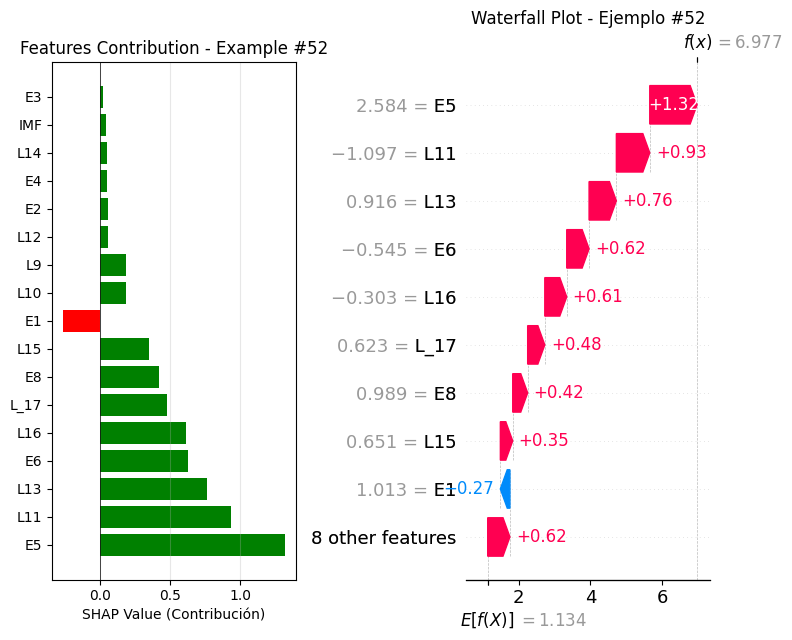

(   Feature  Feature_Value  SHAP_Value  Abs_SHAP
 7       E5       2.583776    1.320583  1.320583
 1      L11      -1.096853    0.932477  0.932477
 2      L13       0.916181    0.761380  0.761380
 10      E6      -0.544735    0.623784  0.623784
 5      L16      -0.302929    0.612538  0.612538
 13    L_17       0.622787    0.477498  0.477498
 3       E8       0.989468    0.417406  0.417406
 14     L15       0.650526    0.345169  0.345169
 12      E1       1.012517   -0.266931  0.266931
 8      L10       1.065438    0.182138  0.182138
 16      L9       0.589437    0.180057  0.180057
 15     L12       0.713022    0.054110  0.054110
 11      E2       1.070362    0.050855  0.050855
 0       E4       0.697232    0.047728  0.047728
 9      L14       0.607797    0.045837  0.045837
 4      IMF       0.434175    0.038157  0.038157
 6       E3      -0.092859    0.020874  0.020874,
 array([9.32025006e-04, 9.99067975e-01]),
 'ENTAILMENT',
 'ENTAILMENT')

In [234]:
analyze_example_with_shap(52, df_X_test_C_E.drop(columns=["clases"]), df_X_test_C_E["clases"], shap_values, m_C_E, explainer)

ANÁLISIS SHAP PARA EJEMPLO #1435
📊 Etiqueta verdadera: CONTRADICTION
🤖 Predicción del modelo: ENTAILMENT
📈 Probabilidades: CONTRADICTION=0.005, ENTAILMENT=0.995

📋 TOP 5 CARACTERÍSTICAS MÁS INFLUYENTES:
----------------------------------------------------------------------
L13                  SHAP:  1.3872 ↑ FAVORECE ENTAILMENT
                      Valor: 1.6278
L11                  SHAP:  0.9325 ↑ FAVORECE ENTAILMENT
                      Valor: -1.0969
L_17                 SHAP:  0.7911 ↑ FAVORECE ENTAILMENT
                      Valor: 1.0354
E8                   SHAP:  0.7635 ↑ FAVORECE ENTAILMENT
                      Valor: 1.5479
L15                  SHAP:  0.4972 ↑ FAVORECE ENTAILMENT
                      Valor: 1.0433

📐 Valor base (log-odds): 1.1336
📐 Suma de SHAP values: 4.1618
📐 Log-odds final: 5.2954
📐 Probabilidad calculada: 0.9950 (vs modelo: 0.9950)



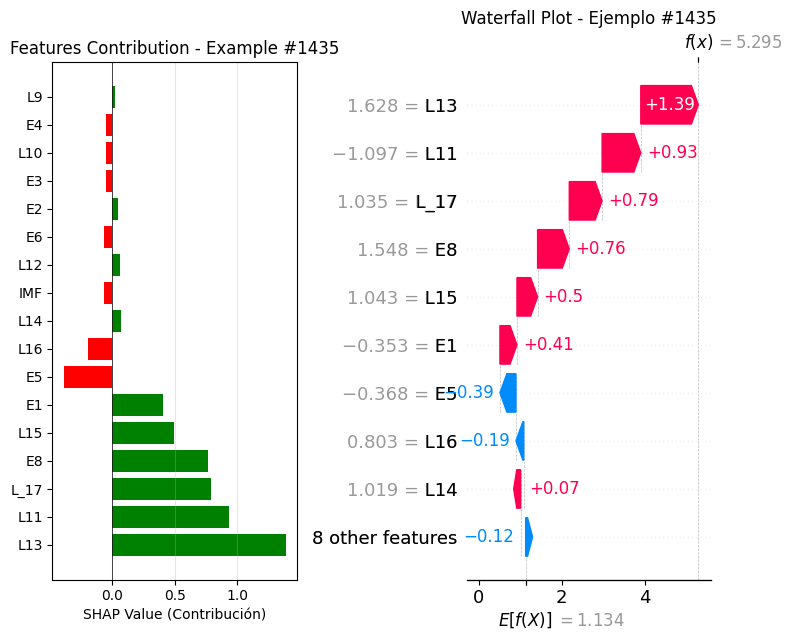

(   Feature  Feature_Value  SHAP_Value  Abs_SHAP
 2      L13       1.627778    1.387189  1.387189
 1      L11      -1.096853    0.932477  0.932477
 13    L_17       1.035442    0.791078  0.791078
 3       E8       1.547851    0.763497  0.763497
 14     L15       1.043311    0.497152  0.497152
 12      E1      -0.353247    0.410607  0.410607
 7       E5      -0.367702   -0.385991  0.385991
 5      L16       0.803479   -0.187454  0.187454
 9      L14       1.019455    0.074758  0.074758
 4      IMF      -1.156331   -0.065915  0.065915
 15     L12       0.728710    0.064478  0.064478
 10      E6       0.739933   -0.063145  0.063145
 11      E2       1.070362    0.050855  0.050855
 6       E3       1.125811   -0.048087  0.048087
 8      L10      -0.165337   -0.044067  0.044067
 0       E4      -1.606259   -0.043869  0.043869
 16      L9      -0.137741    0.028233  0.028233,
 array([0.00498981, 0.99501019]),
 'ENTAILMENT',
 'CONTRADICTION')

In [235]:
analyze_example_with_shap(1435, df_X_test_C_E.drop(columns=["clases"]), df_X_test_C_E["clases"], shap_values, m_C_E, explainer)

ANÁLISIS SHAP PARA EJEMPLO #250
📊 Etiqueta verdadera: CONTRADICTION
🤖 Predicción del modelo: CONTRADICTION
📈 Probabilidades: CONTRADICTION=0.994, ENTAILMENT=0.006

📋 TOP 5 CARACTERÍSTICAS MÁS INFLUYENTES:
----------------------------------------------------------------------
E5                   SHAP: -2.3878 ↓ FAVORECE CONTRADICTION
                      Valor: -3.8297
L11                  SHAP: -1.6355 ↓ FAVORECE CONTRADICTION
                      Valor: 1.9849
E1                   SHAP: -1.0058 ↓ FAVORECE CONTRADICTION
                      Valor: 2.5019
L13                  SHAP: -0.9909 ↓ FAVORECE CONTRADICTION
                      Valor: -1.0763
L_17                 SHAP: -0.9747 ↓ FAVORECE CONTRADICTION
                      Valor: -1.2882

📐 Valor base (log-odds): 1.1336
📐 Suma de SHAP values: -6.2966
📐 Log-odds final: -5.1630
📐 Probabilidad calculada: 0.0057 (vs modelo: 0.0057)



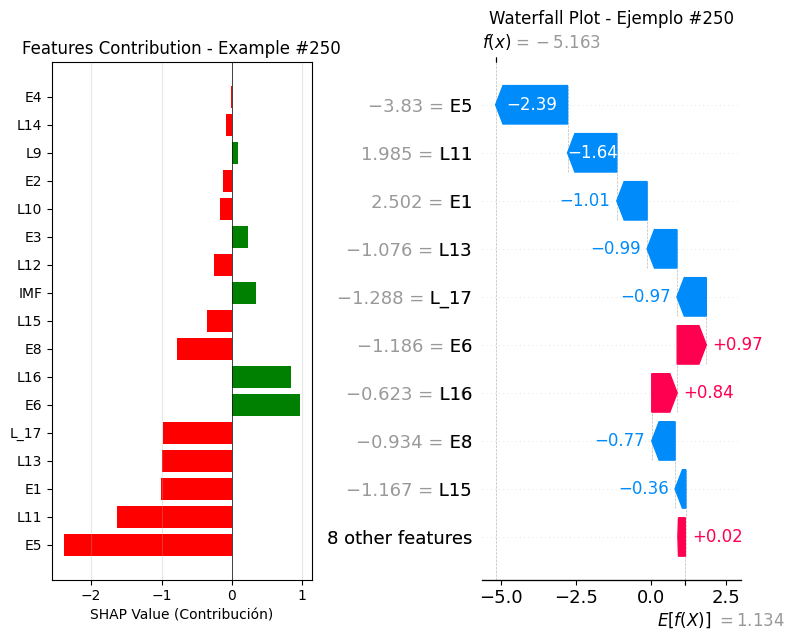

(   Feature  Feature_Value  SHAP_Value  Abs_SHAP
 7       E5      -3.829718   -2.387763  2.387763
 1      L11       1.984934   -1.635537  1.635537
 12      E1       2.501946   -1.005818  1.005818
 2      L13      -1.076347   -0.990937  0.990937
 13    L_17      -1.288231   -0.974703  0.974703
 10      E6      -1.185850    0.966597  0.966597
 5      L16      -0.623205    0.844114  0.844114
 3       E8      -0.933850   -0.774685  0.774685
 14     L15      -1.167481   -0.358285  0.358285
 4      IMF       5.205692    0.350374  0.350374
 15     L12       0.253792   -0.249384  0.249384
 6       E3      -3.748870    0.227759  0.227759
 8      L10      -0.842248   -0.168477  0.168477
 11      E2      -0.868782   -0.130965  0.130965
 16      L9       0.160046    0.090407  0.090407
 9      L14      -1.297559   -0.088024  0.088024
 0       E4      -0.785739   -0.011241  0.011241,
 array([0.99430814, 0.00569186]),
 'CONTRADICTION',
 'CONTRADICTION')

In [237]:
analyze_example_with_shap(250, df_X_test_C_E.drop(columns=["clases"]), df_X_test_C_E["clases"], shap_values, m_C_E, explainer)